# CIGRE LV State Estimation Uncertainty Quantification

## Goal

This notebook compares five uncertainty-quantification paths on the [CIGRE low-voltage distribution network](https://pandapower.readthedocs.io/en/latest/networks/cigre.html#low-voltage-distribution-network) distributed with pandapower:

1. analytical UQ with iterative-linear state estimation (ILSE);
2. analytical UQ with Newton–Raphson state estimation (NRSE);
3. conventional gain-inverse UQ at the NRSE operating point;
4. Monte Carlo UQ with ILSE; and
5. Monte Carlo UQ with NRSE.

The gain-inverse path builds $G=H^\mathsf{T}WH$ from sensor rows only. It deliberately excludes exact zero-injection constraints; one angle coordinate is removed only in any otherwise unanchored measurement subnetwork.

| Plot label | State estimator | Uncertainty calculation | Exact zero injection |
|---|---|---|---|
| Analytical UQ ILSE | ILSE | PGM analytical propagation | Included |
| Analytical UQ NRSE | NRSE | PGM analytical propagation | Included |
| UQ gain inv | Converged NRSE operating point | $G^{-1}$ plus first-order output propagation | Excluded |
| Monte Carlo UQ ILSE | ILSE | Sample standard deviation, $N=1{,}000$ | Included |
| Monte Carlo UQ NRSE | NRSE | Sample standard deviation, $N=1{,}000$ | Included |

The comparison is repeated for three sensor layouts:

- voltage sensors + current sensors;
- voltage sensors + power sensors; and
- voltage sensors + current sensors + power sensors.

The combined layout places current sensors at every line and transformer from-terminal and power sensors at every corresponding to-terminal. This respects PGM's rule that power and current sensors may not share the same terminal of the same branch.

## Setup

The input is loaded from the adjacent `data/cigre_lv_pgm.json` file. It was generated from `pandapower.networks.create_cigre_network_lv()` with the Power Grid Model IO pandapower converter. The original pandapower model contains 44 buses, 37 lines, 3 transformers, 3 closed bus-bus switches, 15 loads, and one external grid. The conversion fuses the three buses joined to the source bus by closed ideal switches, preserving their electrical equivalence while avoiding zero-impedance PGM links. The resulting PGM model has 41 nodes. The converter also splits each pandapower ZIP load into constant-power, constant-current, and constant-impedance PGM load rows.

The measurement uncertainties are scaled for the mixed 20 kV / 0.4 kV network:

- voltage magnitude sigma: 0.125% of rated voltage (25 V at 20 kV and 0.5 V at 0.4 kV);
- voltage-angle sigma: the same relative scale multiplied by $2\pi$;
- current magnitude sigma: 0.5 A;
- current-angle sigma: 0.01 rad;
- power P sigma: 1 kW; and
- power Q sigma: 1 kvar.

Monte Carlo updates are generated with PGM's public-coordinate helper and a fixed seed.

In [1]:
import sys
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import power_grid_model
from power_grid_model import (
    AngleMeasurementType,
    AttributeType,
    CalculationMethod,
    CalculationType,
    ComponentType,
    DatasetType,
    MeasuredTerminalType,
    PowerGridModel,
    initialize_array,
)
from power_grid_model._core.power_grid_model_c.get_pgm_dll_path import get_pgm_dll_path
from power_grid_model.utils import create_state_estimation_monte_carlo_updates
from power_grid_model.validation import assert_valid_input_data

example_directory = Path("docs/examples") if Path("docs/examples").is_dir() else Path()
example_directory_string = str(example_directory.resolve())
if example_directory_string not in sys.path:
    sys.path.insert(0, example_directory_string)
from gain_covariance import propagate_covariance
from gain_matrix import build_gain_matrix

output_directory = Path("docs/examples/output/cigre_lv") if Path("docs/examples").is_dir() else Path("output/cigre_lv")
output_directory.mkdir(parents=True, exist_ok=True)

print("Python:", sys.executable)
print("Power Grid Model package:", power_grid_model.__file__)
print("Native library:", get_pgm_dll_path())

Python: /home/jhe/pgm_dev/power-grid-model/.venv/bin/python
Power Grid Model package: /home/jhe/pgm_dev/power-grid-model/src/power_grid_model/__init__.py
Native library: /home/jhe/pgm_dev/power-grid-model/build/bin/libpower_grid_model_c.so


In [2]:
# ruff: noqa: E501
import json

data_file_candidates = [
    Path("data/cigre_lv_pgm.json"),
    Path("docs/examples/data/cigre_lv_pgm.json"),
]
data_file = next((path for path in data_file_candidates if path.exists()), None)
if data_file is None:
    raise FileNotFoundError(
        "Could not find cigre_lv_pgm.json. Run this notebook from the repository root or from docs/examples."
    )
with data_file.open() as file:
    converted_model = json.load(file)


def deserialize_converted_model(component_rows):
    input_data = {}
    for component_name, rows in component_rows.items():
        component = ComponentType(component_name)
        array = initialize_array(DatasetType.input, component, len(rows))
        common_fields = set(rows[0]).intersection(array.dtype.names)
        for row in rows[1:]:
            common_fields.intersection_update(row)
        for field in sorted(common_fields):
            array[field] = [row[field] for row in rows]
        input_data[component] = array
    return input_data


base_input_data = deserialize_converted_model(converted_model)
assert_valid_input_data(
    base_input_data,
    calculation_type=CalculationType.power_flow,
    symmetric=True,
)
print({str(component): len(values) for component, values in base_input_data.items()})

{'node': 41, 'line': 37, 'source': 1, 'sym_load': 45, 'transformer': 3}


## Network summary

This table is computed from the physical components in the PGM input data; measurement sensors are not counted. A **zero-injection bus** follows PGM's exact state-estimation definition: it has no connected in-service source, load, or generator. Shunts are modeled separately, while a connected appliance with a zero numerical setpoint still counts as an appliance.

In [3]:
from pathlib import Path

network_summary_directory = Path("docs/examples") if Path("docs/examples").is_dir() else Path()
network_summary_directory_string = str(network_summary_directory.resolve())
if network_summary_directory_string not in sys.path:
    sys.path.insert(0, network_summary_directory_string)
from network_summary import network_summary_rows

network_summary_table = pd.DataFrame(network_summary_rows(base_input_data))
network_summary_table

,Metric,Value
0,Buses,41
1,Nominal voltage levels [kV],"0.4, 20"
2,Branch elements,40
3,In-service branch elements,40
4,Open branch elements,0
5,Lines,37
6,Transformers,3
7,Two-winding transformers,3
8,Three-winding transformers,0
9,Links and generic branches,0


## CIGRE LV topology

The topology figure is generated from the converted CIGRE LV model and saved alongside the UQ figures. The source pandapower network has 44 buses and three closed ideal bus-bus switches. Fusing those electrically identical 20 kV buses gives 41 PGM nodes and three feeder sections:

- residential feeder: transformer 124 and PGM nodes 1–18;
- industrial feeder: transformer 125 and PGM nodes 19–20; and
- commercial feeder: transformer 126 and PGM nodes 21–40.

All 37 lines and 3 transformers are in service; there are no open branch elements.

<img src="output/cigre_lv/figures/cigre_lv_topology.png" alt="CIGRE LV network topology" width="900" />

In [4]:
# Record and verify the switch fusion used during conversion.
fused_switch_table = pd.DataFrame(
    [
        {"pandapower switch": "S1", "original endpoints": "0-1", "retained PGM node": 0},
        {"pandapower switch": "S2", "original endpoints": "0-20", "retained PGM node": 0},
        {"pandapower switch": "S3", "original endpoints": "0-23", "retained PGM node": 0},
    ]
)
if ComponentType.link in base_input_data:
    raise ValueError("Closed ideal bus switches should be fused before PGM conversion")
fused_switch_table

,pandapower switch,original endpoints,retained PGM node
0,S1,0-1,0
1,S2,0-20,0
2,S3,0-23,0


## Build the three sensor layouts

All layouts use the same power-flow operating point to generate noisy measurements. The current phasor is reconstructed from the three-phase power-flow branch power and line-to-line terminal voltage using `I = (S / (√3 U))*`.

In [5]:
# ruff: noqa: E501, PLR0915
voltage_sensor_ids = np.array([0, 1, 19, 21])
voltage_relative_sigma = 0.00125
current_sigma = 0.5
current_angle_sigma = 0.01
power_p_sigma = 1_000.0
power_q_sigma = 1_000.0
sensor_seed = 42


def max_component_id(input_data):
    return max(int(np.max(values[AttributeType.id])) for values in input_data.values())


def make_sensor_input(sensor_setting, seed=sensor_seed):
    input_data = {component: values.copy() for component, values in base_input_data.items()}
    power_flow = PowerGridModel(input_data, system_frequency=50.0).calculate_power_flow(
        symmetric=True,
        calculation_method=CalculationMethod.newton_raphson,
        error_tolerance=1e-8,
        max_iterations=100,
    )
    rng = np.random.default_rng(seed)
    node_ids = input_data[ComponentType.node][AttributeType.id]
    node_index = {int(node_id): index for index, node_id in enumerate(node_ids)}
    voltage_index = np.array([node_index[int(node_id)] for node_id in voltage_sensor_ids])
    voltage_ratings = input_data[ComponentType.node][AttributeType.u_rated][voltage_index]
    voltage_sigmas = voltage_relative_sigma * voltage_ratings
    voltage_angle_sigmas = voltage_relative_sigma * 2.0 * np.pi * np.ones(len(voltage_sensor_ids))
    branch_components = [
        component_type
        for component_type in (ComponentType.line, ComponentType.transformer)
        if component_type in input_data and len(input_data[component_type])
    ]
    branch_ids = np.concatenate([input_data[component_type][AttributeType.id] for component_type in branch_components])
    branch_from_nodes = np.concatenate(
        [input_data[component_type][AttributeType.from_node] for component_type in branch_components]
    )
    branch_from_index = np.array([node_index[int(node_id)] for node_id in branch_from_nodes])

    max_id = max_component_id(input_data)
    voltage_sensor = initialize_array(DatasetType.input, ComponentType.sym_voltage_sensor, len(voltage_sensor_ids))
    voltage_sensor[AttributeType.id] = np.arange(max_id + 1, max_id + 1 + len(voltage_sensor_ids))
    voltage_sensor[AttributeType.measured_object] = voltage_sensor_ids
    voltage_sensor[AttributeType.u_sigma] = voltage_sigmas
    voltage_sensor[AttributeType.u_measured] = power_flow[ComponentType.node][AttributeType.u][
        voltage_index
    ] + rng.normal(0.0, voltage_sigmas)
    voltage_sensor[AttributeType.u_angle_measured] = power_flow[ComponentType.node][AttributeType.u_angle][
        voltage_index
    ] + rng.normal(0.0, voltage_angle_sigmas)
    max_id += len(voltage_sensor_ids)

    u_from = power_flow[ComponentType.node][AttributeType.u][branch_from_index] * np.exp(
        1j * power_flow[ComponentType.node][AttributeType.u_angle][branch_from_index]
    )
    s_from = np.concatenate(
        [
            power_flow[component_type][AttributeType.p_from] + 1j * power_flow[component_type][AttributeType.q_from]
            for component_type in branch_components
        ]
    )
    i_from = np.conj(s_from / (np.sqrt(3.0) * u_from))
    np.testing.assert_allclose(
        np.abs(i_from),
        np.concatenate([power_flow[component_type][AttributeType.i_from] for component_type in branch_components]),
        rtol=1e-6,
        atol=1e-8,
    )

    sensors = input_data | {ComponentType.sym_voltage_sensor: voltage_sensor}
    if sensor_setting in {"voltage + current", "voltage + current + power"}:
        current_count = len(branch_ids)
        current_sensor = initialize_array(DatasetType.input, ComponentType.sym_current_sensor, current_count)
        current_sensor[AttributeType.id] = np.arange(max_id + 1, max_id + 1 + current_count)
        current_sensor[AttributeType.measured_object] = branch_ids
        current_sensor[AttributeType.measured_terminal_type] = MeasuredTerminalType.branch_from
        current_sensor[AttributeType.angle_measurement_type] = AngleMeasurementType.global_angle
        current_sensor[AttributeType.i_sigma] = current_sigma
        current_sensor[AttributeType.i_angle_sigma] = current_angle_sigma
        current_sensor[AttributeType.i_measured] = np.abs(i_from) + rng.normal(0.0, current_sigma, current_count)
        current_sensor[AttributeType.i_angle_measured] = np.angle(i_from) + rng.normal(
            0.0, current_angle_sigma, current_count
        )
        sensors[ComponentType.sym_current_sensor] = current_sensor
        max_id += current_count

    if sensor_setting in {"voltage + power", "voltage + current + power"}:
        power_count = len(branch_ids)
        power_sensor = initialize_array(DatasetType.input, ComponentType.sym_power_sensor, power_count)
        power_sensor[AttributeType.id] = np.arange(max_id + 1, max_id + 1 + power_count)
        power_sensor[AttributeType.measured_object] = branch_ids
        power_sensor[AttributeType.measured_terminal_type] = MeasuredTerminalType.branch_to
        power_sensor[AttributeType.p_sigma] = power_p_sigma
        power_sensor[AttributeType.q_sigma] = power_q_sigma
        p_to = np.concatenate([power_flow[component_type][AttributeType.p_to] for component_type in branch_components])
        q_to = np.concatenate([power_flow[component_type][AttributeType.q_to] for component_type in branch_components])
        power_sensor[AttributeType.p_measured] = p_to + rng.normal(0.0, power_p_sigma, power_count)
        power_sensor[AttributeType.q_measured] = q_to + rng.normal(0.0, power_q_sigma, power_count)
        sensors[ComponentType.sym_power_sensor] = power_sensor

    assert_valid_input_data(
        sensors,
        calculation_type=CalculationType.state_estimation,
        symmetric=True,
    )
    return sensors


sensor_settings = [
    "voltage + current",
    "voltage + power",
    "voltage + current + power",
]
state_estimation_inputs = {setting: make_sensor_input(setting) for setting in sensor_settings}
pd.DataFrame(
    {
        "sensor setting": sensor_settings,
        "voltage sensors": [len(state_estimation_inputs[s][ComponentType.sym_voltage_sensor]) for s in sensor_settings],
        "current sensors": [
            len(state_estimation_inputs[s].get(ComponentType.sym_current_sensor, [])) for s in sensor_settings
        ],
        "power sensors": [
            len(state_estimation_inputs[s].get(ComponentType.sym_power_sensor, [])) for s in sensor_settings
        ],
    }
)

,sensor setting,voltage sensors,current sensors,power sensors
0,voltage + current,4,40,0
1,voltage + power,4,0,40
2,voltage + current + power,4,40,40


## Analytical UQ and conventional gain inverse

The point estimates and analytical output sigmas are computed from identical sensor inputs. The checks confirm that requesting analytical UQ does not alter the point estimate.
The conventional gain inverse uses the same converged NRSE operating point, but its $H$, $W$, and $G$ contain sensor information only; PGM exact zero-injection constraints are excluded.


In [6]:
methods = {
    "Analytical UQ ILSE": CalculationMethod.iterative_linear,
    "Analytical UQ NRSE": CalculationMethod.newton_raphson,
}
analytical_results = {}
analytical_seconds = {}
deterministic_seconds = {}
gain_inverse_results = {}

for setting, input_data in state_estimation_inputs.items():
    for method_name, calculation_method in methods.items():
        model = PowerGridModel(input_data, system_frequency=50.0)
        start = perf_counter()
        without_uq = model.calculate_state_estimation(
            calculation_method=calculation_method,
            error_tolerance=1e-8,
            max_iterations=50,
        )
        deterministic_seconds[setting, method_name] = perf_counter() - start
        start = perf_counter()
        with_uq = model.calculate_state_estimation(
            calculation_method=calculation_method,
            calculate_uncertainty=True,
            error_tolerance=1e-8,
            max_iterations=50,
        )
        analytical_seconds[setting, method_name] = perf_counter() - start
        for component in (ComponentType.node, ComponentType.line):
            for field in ("u", "u_angle", "p", "q", "i_from", "i_to"):
                if field in with_uq[component].dtype.names:
                    np.testing.assert_allclose(with_uq[component][field], without_uq[component][field])
        analytical_results[setting, method_name] = with_uq

    nrse_result = analytical_results[setting, "Analytical UQ NRSE"]
    gain_model = build_gain_matrix(
        input_data,
        state_estimation_result=nrse_result,
        max_gain_matrix_bytes=None,
    )
    measurement_model = gain_model.measurement_model
    gain_inverse = np.linalg.inv(gain_model.gain_matrix)
    del gain_model
    gain_inverse_results[setting] = propagate_covariance(
        input_data,
        measurement_model,
        gain_inverse,
        nrse_result,
    )
    del gain_inverse

pd.DataFrame(
    [
        {"sensor setting": setting, "method": method, "analytical time [s]": analytical_seconds[setting, method]}
        for setting in sensor_settings
        for method in methods
    ]
).round(3)

,sensor setting,method,analytical time [s]
0,voltage + current,Analytical UQ ILSE,0.002
1,voltage + current,Analytical UQ NRSE,0.004
2,voltage + power,Analytical UQ ILSE,0.002
3,voltage + power,Analytical UQ NRSE,0.004
4,voltage + current + power,Analytical UQ ILSE,0.002
5,voltage + current + power,Analytical UQ NRSE,0.004


## Monte Carlo UQ: ILSE and NRSE

The same noisy update batch is used for both state-estimation methods within each sensor setting. Failed batch scenarios are excluded from empirical standard deviations and reported explicitly.

In [7]:
monte_carlo_sample_count = 1_000
monte_carlo_results = {}
monte_carlo_valid = {}
monte_carlo_seconds = {}
benchmark_rows = []

for setting, input_data in state_estimation_inputs.items():
    updates = create_state_estimation_monte_carlo_updates(
        input_data,
        monte_carlo_sample_count,
        seed=2026,
    )
    for method_name, calculation_method in methods.items():
        model = PowerGridModel(input_data, system_frequency=50.0)
        start = perf_counter()
        batch_result = model.calculate_state_estimation(
            calculation_method=calculation_method,
            update_data=updates,
            error_tolerance=1e-8,
            max_iterations=50,
            continue_on_batch_error=True,
        )
        elapsed = perf_counter() - start
        failed = [] if model.batch_error is None else model.batch_error.failed_scenarios
        valid = np.ones(monte_carlo_sample_count, dtype=bool)
        valid[failed] = False
        np.testing.assert_array_less(0.90 * monte_carlo_sample_count, np.count_nonzero(valid))
        monte_carlo_results[setting, method_name] = batch_result
        monte_carlo_valid[setting, method_name] = valid
        monte_carlo_seconds[setting, method_name] = elapsed
        benchmark_rows.append(
            {
                "sensor setting": setting,
                "method": method_name.replace("Analytical", "Monte Carlo"),
                "Monte Carlo time [s]": elapsed,
                "attempted samples": monte_carlo_sample_count,
                "converged samples": int(np.count_nonzero(valid)),
                "time [ms / attempted sample]": 1e3 * elapsed / monte_carlo_sample_count,
            }
        )

monte_carlo_timing_sample_counts = [10, 100, 500, 2_000, 5_000, 10_000]
monte_carlo_scaling_seconds = {}
for setting, input_data in state_estimation_inputs.items():
    for sample_count in monte_carlo_timing_sample_counts:
        updates = create_state_estimation_monte_carlo_updates(
            input_data,
            sample_count,
            seed=2026,
        )
        for method_name, calculation_method in methods.items():
            model = PowerGridModel(input_data, system_frequency=50.0)
            start = perf_counter()
            model.calculate_state_estimation(
                calculation_method=calculation_method,
                update_data=updates,
                error_tolerance=1e-8,
                max_iterations=50,
                continue_on_batch_error=True,
            )
            monte_carlo_scaling_seconds[setting, method_name, sample_count] = perf_counter() - start

pd.DataFrame(benchmark_rows).round(3)

,sensor setting,method,Monte Carlo time [s],attempted samples,converged samples,time [ms / attempted sample]
0,voltage + current,Monte Carlo UQ ILSE,0.276,1000,1000,0.276
1,voltage + current,Monte Carlo UQ NRSE,1.016,1000,1000,1.016
2,voltage + power,Monte Carlo UQ ILSE,0.310,1000,1000,0.310
3,voltage + power,Monte Carlo UQ NRSE,0.876,1000,1000,0.876
4,voltage + current + power,Monte Carlo UQ ILSE,0.319,1000,1000,0.319
5,voltage + current + power,Monte Carlo UQ NRSE,1.019,1000,1000,1.019


## Five-way comparison

The table reports output standard deviations for every CIGRE LV node, line, and transformer quantity. Analytical columns are PGM's propagated sigmas, the gain-inverse column is the sensor-only conventional NRSE covariance, and Monte Carlo columns are sample standard deviations over converged scenarios. Units are SI, with voltage angles in radians.

In [8]:
node_ids = base_input_data[ComponentType.node][AttributeType.id].astype(int)

output_specs = []
for index, node_id in enumerate(node_ids):
    for quantity, value_field, sigma_field, unit in [
        ("voltage magnitude", "u", "u_sigma", "V"),
        ("voltage angle", "u_angle", "u_angle_sigma", "rad"),
        ("active power injection", "p", "p_sigma", "W"),
        ("reactive power injection", "q", "q_sigma", "var"),
    ]:
        output_specs.append(
            {
                "component": "node",
                "id": int(node_id),
                "terminal": "—",
                "quantity": quantity,
                "component_type": ComponentType.node,
                "value_field": value_field,
                "sigma_field": sigma_field,
                "index": index,
                "unit": unit,
            }
        )

for component_type, component_label in [
    (ComponentType.line, "line"),
    (ComponentType.transformer, "transformer"),
]:
    component_ids = base_input_data[component_type][AttributeType.id].astype(int)
    for index, component_id in enumerate(component_ids):
        for terminal, value_suffix in [("from", "from"), ("to", "to")]:
            for quantity, field_prefix, unit in [
                ("current", "i", "A"),
                ("active power", "p", "W"),
                ("reactive power", "q", "var"),
            ]:
                output_specs.append(
                    {
                        "component": component_label,
                        "id": int(component_id),
                        "terminal": terminal,
                        "quantity": quantity,
                        "component_type": component_type,
                        "value_field": f"{field_prefix}_{value_suffix}",
                        "sigma_field": f"{field_prefix}_{value_suffix}_sigma",
                        "index": index,
                        "unit": unit,
                    }
                )

comparison_rows = []
for setting in sensor_settings:
    for spec in output_specs:
        row = {
            "sensor setting": setting,
            "component": spec["component"],
            "id": spec["id"],
            "terminal": spec["terminal"],
            "quantity": spec["quantity"],
            "unit": spec["unit"],
        }
        for method_name in methods:
            analytical = analytical_results[setting, method_name][spec["component_type"]][spec["sigma_field"]][
                spec["index"]
            ]
            valid = monte_carlo_valid[setting, method_name]
            sampled = monte_carlo_results[setting, method_name][spec["component_type"]][spec["value_field"]][
                valid, spec["index"]
            ]
            row[f"{method_name} sigma"] = float(analytical)
            row[f"Monte Carlo UQ {method_name.split()[-1]} sigma"] = float(np.std(sampled, ddof=1))
        row["UQ gain inv sigma"] = float(
            gain_inverse_results[setting][spec["component_type"]][spec["sigma_field"]][spec["index"]]
        )
        comparison_rows.append(row)

comparison = pd.DataFrame(comparison_rows)
numeric_columns = [
    "Analytical UQ ILSE sigma",
    "Analytical UQ NRSE sigma",
    "UQ gain inv sigma",
    "Monte Carlo UQ ILSE sigma",
    "Monte Carlo UQ NRSE sigma",
]
np.testing.assert_array_equal(
    np.isinf(comparison[numeric_columns].to_numpy()),
    np.zeros_like(comparison[numeric_columns].to_numpy(), dtype=bool),
)
comparison = comparison[["sensor setting", "component", "id", "terminal", "quantity", "unit", *numeric_columns]]
comparison_file = output_directory / "cigre_lv_uq_comparison.csv"
comparison.to_csv(comparison_file, index=False)
print(f"Comparison rows: {len(comparison):,}")
print(f"Comparison table exported to {comparison_file}")

Comparison rows: 1,212
Comparison table exported to docs/examples/output/cigre_lv/cigre_lv_uq_comparison.csv


## Agreement with Monte Carlo UQ NRSE

Monte Carlo UQ NRSE with 1,000 attempted samples is the reference for every output. The three scorecards below separately summarize voltage, current, and power sigmas. Voltage covers node voltage magnitude and angle; current covers both line and transformer terminals; power covers node injections and active/reactive power at both line and transformer terminals. They use dimensionless pointwise errors so quantities with different units are not combined as raw errors. The per-quantity CSV retains native-unit errors for each individual quantity.

| Metric | Purpose | Outlier behavior |
|---|---|---|
| Median APE | Typical relative difference from the reference | Robust, but excludes zero reference sigmas |
| Mean APE | Average relative difference | Sensitive to large relative errors |
| P90 APE | Upper-tail relative difference | Shows tail behavior without using the maximum |
| Mean sAPE | Bounded symmetric relative difference (0–200%) | Includes zero-reference cases without unbounded division |
| Median factor error | Typical multiplicative mismatch; 1.0 is exact | Robust, but requires both sigmas to be positive |
| Within 10% / 25% | Share of outputs close to the reference | Easy to interpret; excludes zero reference sigmas |
| Spearman rho | Agreement in output ranking | Rank-based and outlier-resistant, but not a closeness metric |

APE-based and threshold metrics use only finite pairs with a strictly positive Monte Carlo NRSE sigma. Mean sAPE uses every finite pair and defines two zero sigmas as an exact match. Counts in the scorecards make these exclusions visible. Because the Monte Carlo reference is itself estimated from a finite sample, small differences should not be interpreted as deterministic errors.

In [9]:
accuracy_file_prefix = "cigre_lv_uq"
accuracy_comparison = comparison.copy()
if "sensor setting" not in accuracy_comparison.columns:
    accuracy_comparison.insert(0, "sensor setting", "voltage + power")
accuracy_sensor_settings = accuracy_comparison["sensor setting"].drop_duplicates().tolist()

baseline_column = "Monte Carlo UQ NRSE sigma"
candidate_methods = {
    "Analytical UQ ILSE sigma": "Analytical UQ ILSE",
    "Analytical UQ NRSE sigma": "Analytical UQ NRSE",
    "UQ gain inv sigma": "UQ gain inv",
    "Monte Carlo UQ ILSE sigma": "Monte Carlo UQ ILSE",
}
identifier_columns = ["sensor setting", "component", "id", "terminal", "quantity", "unit"]

agreement = accuracy_comparison.melt(
    id_vars=[*identifier_columns, baseline_column],
    value_vars=list(candidate_methods),
    var_name="method column",
    value_name="method sigma",
)
agreement["method"] = agreement["method column"].map(candidate_methods)

finite_pair = np.isfinite(agreement["method sigma"]) & np.isfinite(agreement[baseline_column])
positive_reference = finite_pair & (agreement[baseline_column] > 0.0)
positive_pair = positive_reference & (agreement["method sigma"] > 0.0)
agreement["absolute error"] = np.where(
    finite_pair,
    np.abs(agreement["method sigma"] - agreement[baseline_column]),
    np.nan,
)
agreement["absolute percentage error [%]"] = np.nan
agreement.loc[positive_reference, "absolute percentage error [%]"] = (
    100.0 * agreement.loc[positive_reference, "absolute error"] / agreement.loc[positive_reference, baseline_column]
)
symmetric_denominator = agreement["method sigma"].abs() + agreement[baseline_column].abs()
agreement["symmetric absolute percentage error [%]"] = np.nan
both_zero = finite_pair & (symmetric_denominator == 0.0)
nonzero_symmetric_denominator = finite_pair & (symmetric_denominator > 0.0)
agreement.loc[both_zero, "symmetric absolute percentage error [%]"] = 0.0
agreement.loc[nonzero_symmetric_denominator, "symmetric absolute percentage error [%]"] = (
    200.0
    * agreement.loc[nonzero_symmetric_denominator, "absolute error"]
    / symmetric_denominator[nonzero_symmetric_denominator]
)
agreement["factor error"] = np.nan
sigma_ratio = agreement.loc[positive_pair, "method sigma"] / agreement.loc[positive_pair, baseline_column]
agreement.loc[positive_pair, "factor error"] = np.maximum(sigma_ratio, 1.0 / sigma_ratio)


def summarize_agreement(group):
    valid = group[np.isfinite(group["absolute error"])]
    relative_error = valid["absolute percentage error [%]"].dropna()
    symmetric_error = valid["symmetric absolute percentage error [%]"].dropna()
    factor_error = valid["factor error"].dropna()
    rank_correlation = valid["method sigma"].rank().corr(valid[baseline_column].rank())
    return {
        "finite output pairs": len(valid),
        "zero reference outputs": int((valid[baseline_column] == 0.0).sum()),
        "median APE [%]": relative_error.median(),
        "mean APE [%]": relative_error.mean(),
        "P90 APE [%]": relative_error.quantile(0.90),
        "mean sAPE [%]": symmetric_error.mean(),
        "median factor error [x]": factor_error.median(),
        "within 10% [%]": 100.0 * relative_error.le(10.0).mean(),
        "within 25% [%]": 100.0 * relative_error.le(25.0).mean(),
        "Spearman rho": rank_correlation,
    }


def baseline_converged_sample_count(setting):
    setting_key = (setting, "Analytical UQ NRSE")
    if setting_key in monte_carlo_valid:
        return int(np.count_nonzero(monte_carlo_valid[setting_key]))
    if "Analytical UQ NRSE" in monte_carlo_valid:
        return int(np.count_nonzero(monte_carlo_valid["Analytical UQ NRSE"]))
    raise KeyError(f"No Monte Carlo UQ NRSE validity mask for {setting}")


sigma_categories = {
    "Voltage sigmas": ("voltage magnitude", "voltage angle"),
    "Current sigmas": ("current",),
    "Power sigmas": (
        "active power injection",
        "reactive power injection",
        "active power",
        "reactive power",
    ),
}
agreement["sigma category"] = pd.NA
for category, quantities in sigma_categories.items():
    agreement.loc[agreement["quantity"].isin(quantities), "sigma category"] = category
if agreement["sigma category"].isna().any():
    raise RuntimeError("Every output quantity must belong to one sigma category")

agreement_summary_rows = []
for setting in accuracy_sensor_settings:
    for method in candidate_methods.values():
        group = agreement[(agreement["sensor setting"] == setting) & (agreement["method"] == method)]
        agreement_summary_rows.append(
            {
                "sensor setting": setting,
                "method": method,
                "baseline attempted samples": monte_carlo_sample_count,
                "baseline converged samples": baseline_converged_sample_count(setting),
                **summarize_agreement(group),
            }
        )
agreement_summary = pd.DataFrame(agreement_summary_rows)

agreement_by_category_rows = []
for category in sigma_categories:
    for setting in accuracy_sensor_settings:
        for method in candidate_methods.values():
            group = agreement[
                (agreement["sigma category"] == category)
                & (agreement["sensor setting"] == setting)
                & (agreement["method"] == method)
            ]
            agreement_by_category_rows.append(
                {
                    "sigma category": category,
                    "sensor setting": setting,
                    "method": method,
                    "baseline attempted samples": monte_carlo_sample_count,
                    "baseline converged samples": baseline_converged_sample_count(setting),
                    **summarize_agreement(group),
                }
            )
agreement_by_category = pd.DataFrame(agreement_by_category_rows)

agreement_by_quantity_rows = []
quantity_group_columns = ["sensor setting", "method", "component", "terminal", "quantity", "unit"]
for keys, group in agreement.groupby(quantity_group_columns, sort=False):
    valid = group[np.isfinite(group["absolute error"])]
    metrics = summarize_agreement(group)
    metrics.update(
        {
            "MAE": valid["absolute error"].mean(),
            "median absolute error": valid["absolute error"].median(),
            "RMSE": np.sqrt(np.mean(np.square(valid["absolute error"]))),
            "P90 absolute error": valid["absolute error"].quantile(0.90),
        }
    )
    agreement_by_quantity_rows.append(dict(zip(quantity_group_columns, keys, strict=True)) | metrics)
agreement_by_quantity = pd.DataFrame(agreement_by_quantity_rows)

agreement_summary_file = output_directory / f"{accuracy_file_prefix}_baseline_metrics.csv"
agreement_by_category_file = output_directory / f"{accuracy_file_prefix}_baseline_metrics_by_category.csv"
agreement_by_quantity_file = output_directory / f"{accuracy_file_prefix}_baseline_metrics_by_quantity.csv"
agreement_summary.to_csv(agreement_summary_file, index=False)
agreement_by_category.to_csv(agreement_by_category_file, index=False)
agreement_by_quantity.to_csv(agreement_by_quantity_file, index=False)
print(f"Overall baseline metrics exported to {agreement_summary_file}")
print(f"Category baseline metrics exported to {agreement_by_category_file}")
print(f"Per-quantity baseline metrics exported to {agreement_by_quantity_file}")

category_table_columns = [
    "sensor setting",
    "method",
    "finite output pairs",
    "zero reference outputs",
    "median APE [%]",
    "mean APE [%]",
    "P90 APE [%]",
    "mean sAPE [%]",
    "median factor error [x]",
    "within 10% [%]",
    "within 25% [%]",
    "Spearman rho",
]
category_table_rounding = {
    "median APE [%]": 2,
    "mean APE [%]": 2,
    "P90 APE [%]": 2,
    "mean sAPE [%]": 2,
    "median factor error [x]": 3,
    "within 10% [%]": 1,
    "within 25% [%]": 1,
    "Spearman rho": 3,
}


def format_category_table(category):
    return (
        agreement_by_category.loc[agreement_by_category["sigma category"] == category, category_table_columns]
        .round(category_table_rounding)
        .reset_index(drop=True)
    )

Overall baseline metrics exported to docs/examples/output/cigre_lv/cigre_lv_uq_baseline_metrics.csv
Category baseline metrics exported to docs/examples/output/cigre_lv/cigre_lv_uq_baseline_metrics_by_category.csv
Per-quantity baseline metrics exported to docs/examples/output/cigre_lv/cigre_lv_uq_baseline_metrics_by_quantity.csv


### Voltage sigmas

In [10]:
format_category_table("Voltage sigmas")

,sensor setting,method,finite output pairs,zero reference outputs,median APE [%],mean APE [%],P90 APE [%],mean sAPE [%],median factor error [x],within 10% [%],within 25% [%],Spearman rho
0,voltage + current,Analytical UQ ILSE,82,0,23.50,21.34,23.85,24.00,1.307,1.2,98.8,0.995
1,voltage + current,Analytical UQ NRSE,82,0,3.56,4.98,10.63,5.16,1.037,80.5,100.0,0.995
2,voltage + current,UQ gain inv,82,0,5.55,7.23,8.24,6.66,1.056,92.7,93.9,0.933
3,voltage + current,Monte Carlo UQ ILSE,82,0,3.32,5.40,9.24,5.22,1.033,100.0,100.0,0.998
4,voltage + power,Analytical UQ ILSE,82,0,24.86,24.79,32.29,28.54,1.331,0.0,51.2,0.993
5,voltage + power,Analytical UQ NRSE,82,0,0.95,1.11,2.43,1.12,1.010,100.0,100.0,0.998
6,voltage + power,UQ gain inv,82,0,1.75,2.31,5.01,2.28,1.018,100.0,100.0,0.997
7,voltage + power,Monte Carlo UQ ILSE,82,0,0.29,0.28,0.41,0.28,1.003,100.0,100.0,1.000
8,voltage + current + power,Analytical UQ ILSE,82,0,24.21,24.22,27.86,27.61,1.319,0.0,56.1,0.982
9,voltage + current + power,Analytical UQ NRSE,82,0,0.32,0.46,1.03,0.45,1.003,100.0,100.0,0.996


### Current sigmas

In [11]:
format_category_table("Current sigmas")

,sensor setting,method,finite output pairs,zero reference outputs,median APE [%],mean APE [%],P90 APE [%],mean sAPE [%],median factor error [x],within 10% [%],within 25% [%],Spearman rho
0,voltage + current,Analytical UQ ILSE,80,0,25.76,34.48,81.73,28.53,1.289,17.5,47.5,0.656
1,voltage + current,Analytical UQ NRSE,80,0,18.96,29.95,79.47,24.78,1.234,20.0,57.5,0.681
2,voltage + current,UQ gain inv,80,0,101.59,169.75,338.31,71.01,2.016,5.0,15.0,0.293
3,voltage + current,Monte Carlo UQ ILSE,80,0,0.35,1.32,3.14,1.29,1.003,95.0,100.0,0.994
4,voltage + power,Analytical UQ ILSE,80,0,8.19,8.30,10.70,8.68,1.089,75.0,100.0,0.969
5,voltage + power,Analytical UQ NRSE,80,0,1.64,2.07,3.69,2.06,1.016,100.0,100.0,0.967
6,voltage + power,UQ gain inv,80,0,69.03,73.98,114.02,51.77,1.690,5.0,5.0,0.276
7,voltage + power,Monte Carlo UQ ILSE,80,0,0.08,0.57,0.50,0.55,1.001,97.5,100.0,0.998
8,voltage + current + power,Analytical UQ ILSE,80,0,17.05,16.85,28.18,16.20,1.171,25.0,77.5,0.807
9,voltage + current + power,Analytical UQ NRSE,80,0,14.97,16.05,28.55,15.10,1.162,30.0,70.0,0.801


### Power sigmas

In [12]:
format_category_table("Power sigmas")

,sensor setting,method,finite output pairs,zero reference outputs,median APE [%],mean APE [%],P90 APE [%],mean sAPE [%],median factor error [x],within 10% [%],within 25% [%],Spearman rho
0,voltage + current,Analytical UQ ILSE,242,50,16.69,17.81,37.11,30.03,1.198,29.7,75.5,0.958
1,voltage + current,Analytical UQ NRSE,242,50,16.89,19.01,40.88,33.22,1.187,26.6,71.9,0.945
2,voltage + current,UQ gain inv,242,50,74.55,99.70,221.29,85.35,1.746,10.9,25.0,0.301
3,voltage + current,Monte Carlo UQ ILSE,242,50,0.66,2.10,3.33,1.51,1.007,96.4,97.9,0.999
4,voltage + power,Analytical UQ ILSE,242,50,6.12,5.98,8.92,18.14,1.065,98.4,100.0,0.986
5,voltage + power,Analytical UQ NRSE,242,50,1.43,1.86,3.29,22.12,1.014,100.0,100.0,0.985
6,voltage + power,UQ gain inv,242,50,67.72,71.80,122.92,81.27,1.677,4.7,7.3,-0.445
7,voltage + power,Monte Carlo UQ ILSE,242,50,0.04,0.54,1.01,0.42,1.000,97.9,100.0,1.000
8,voltage + current + power,Analytical UQ ILSE,242,50,12.03,11.91,18.05,22.36,1.126,42.7,93.2,0.962
9,voltage + current + power,Analytical UQ NRSE,242,50,14.22,14.43,23.30,34.96,1.158,35.4,91.7,0.945


## Network-wide comparison figures

The complete 1,212-row comparison is exported to `output/cigre_lv/cigre_lv_uq_comparison.csv` and is not rendered in full in the notebook. The node-voltage, line/transformer-current, and line/transformer-active-power charts are split into readable chunks for each sensor layout. Every output has five bars for the five UQ methods; the exported table retains voltage angle, reactive power, both terminals, and all three component types. The final figure compares deterministic SE, analytical UQ, and Monte Carlo UQ ILSE/NRSE scaling across the three sensor settings.

The `UQ gain inv` bars propagate the inverse of the sensor-only gain matrix and therefore do not include exact zero-injection constraints.

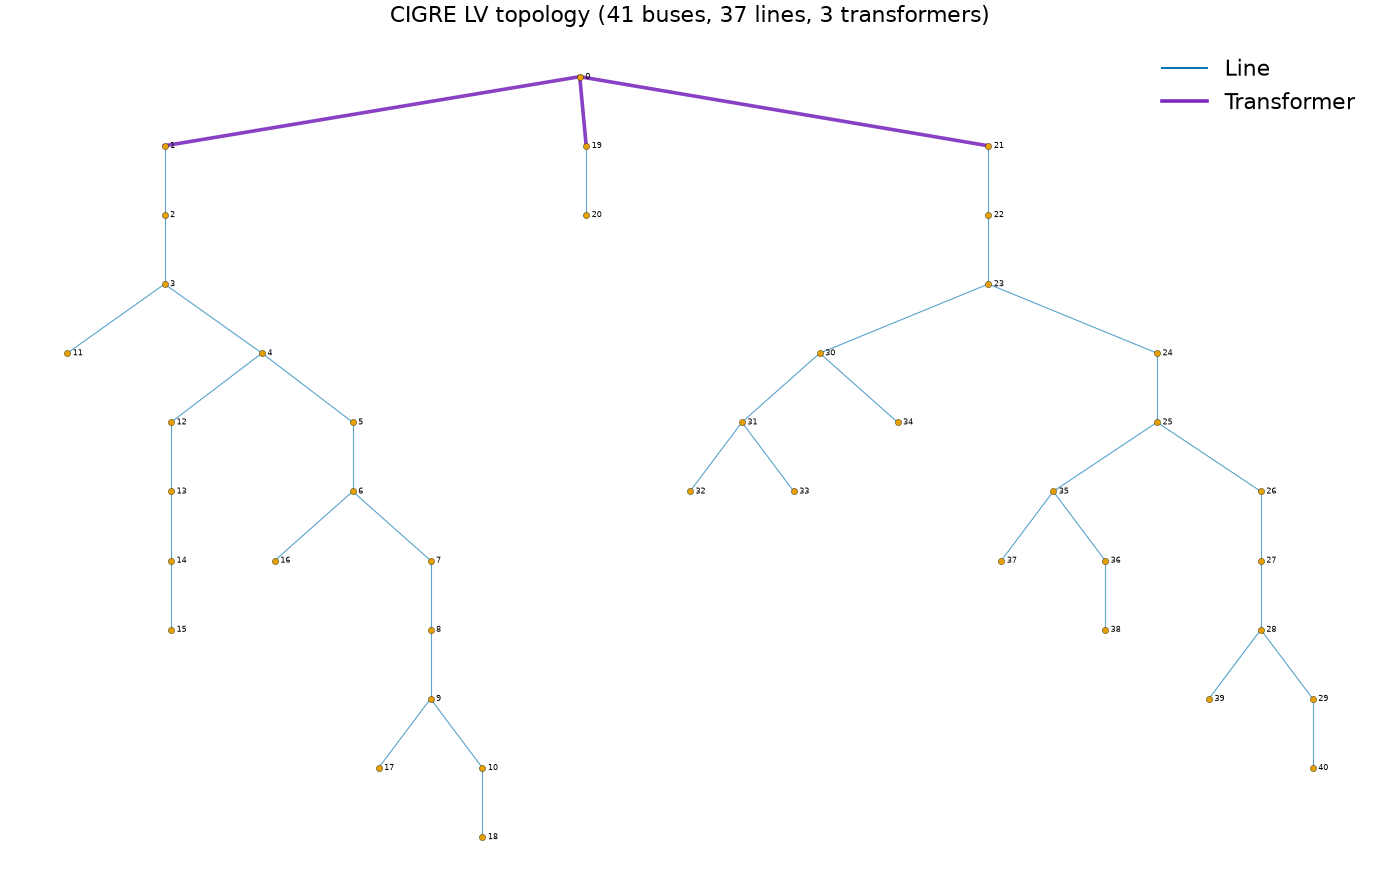

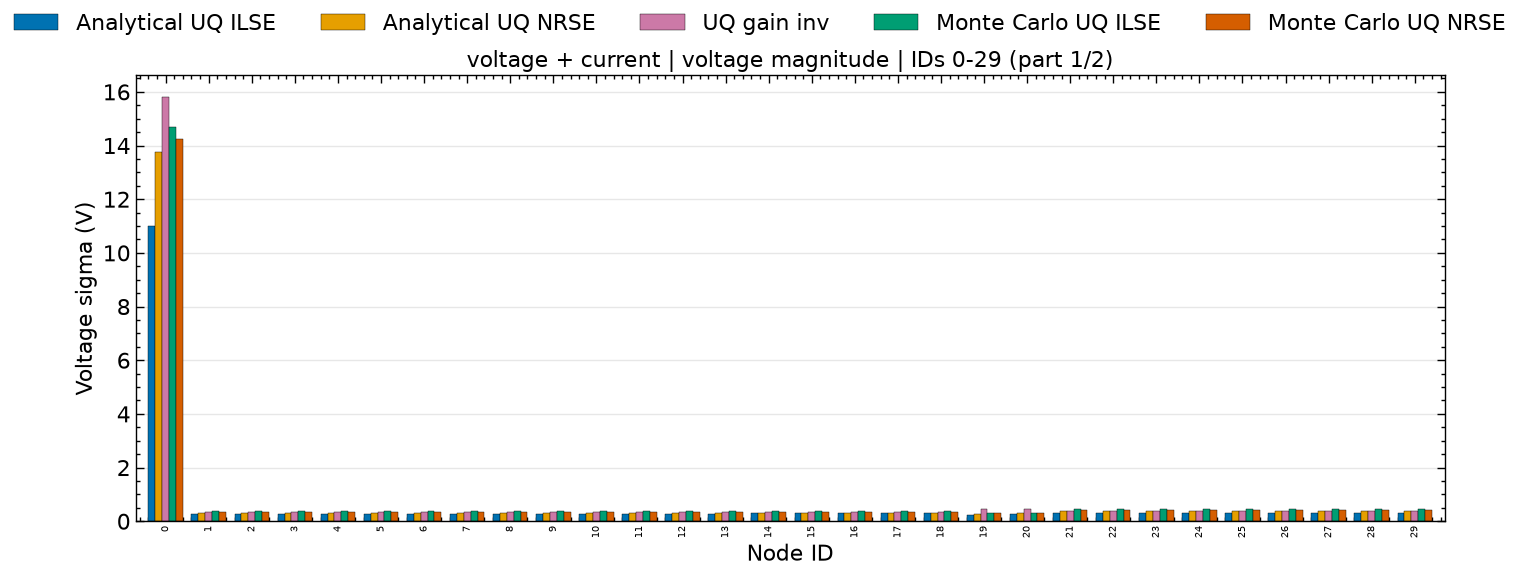

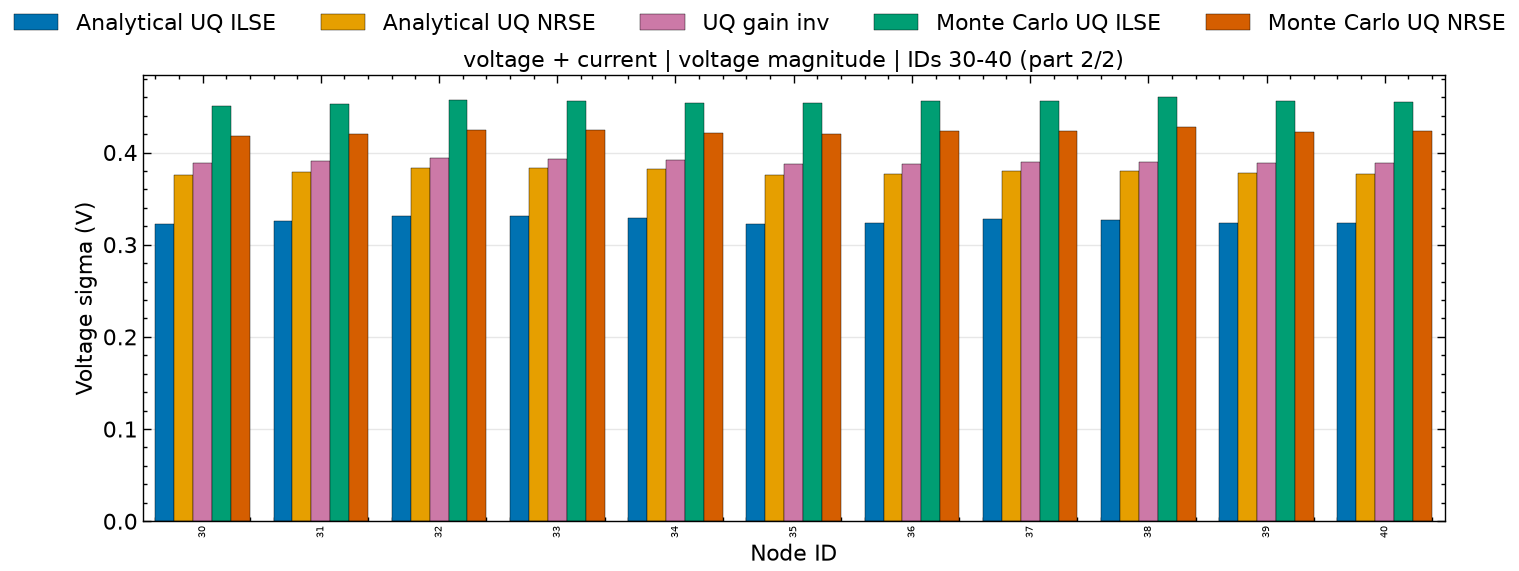

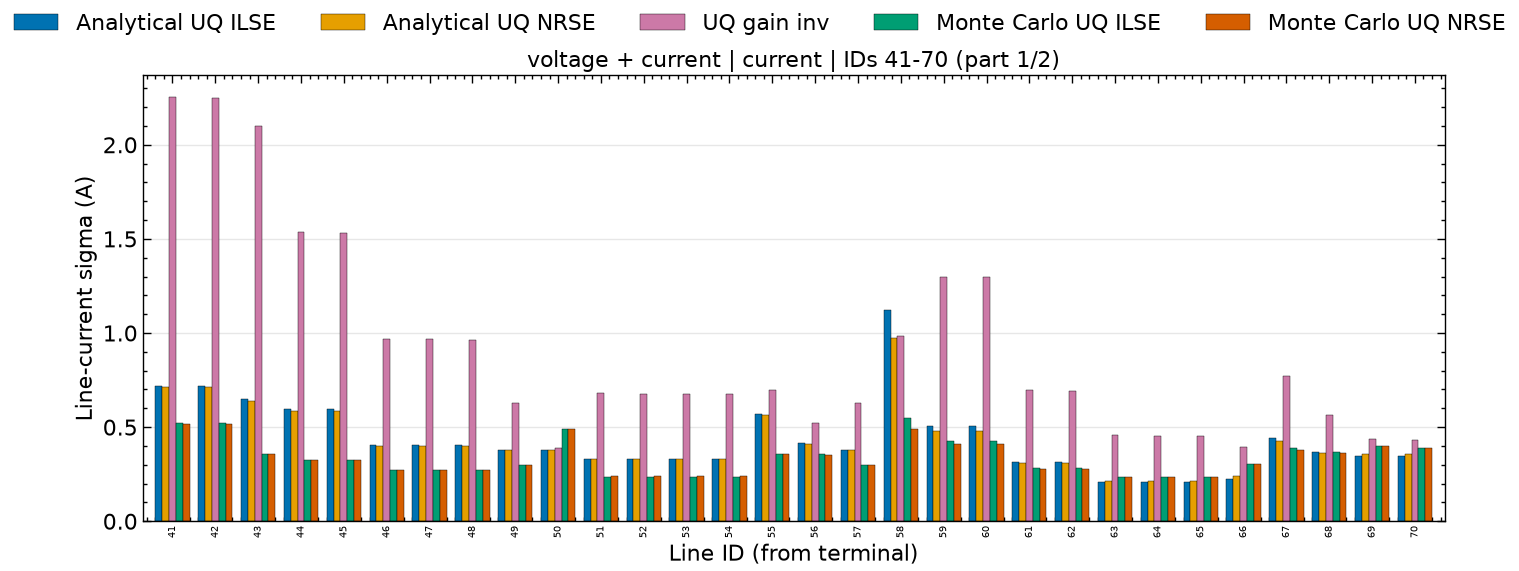

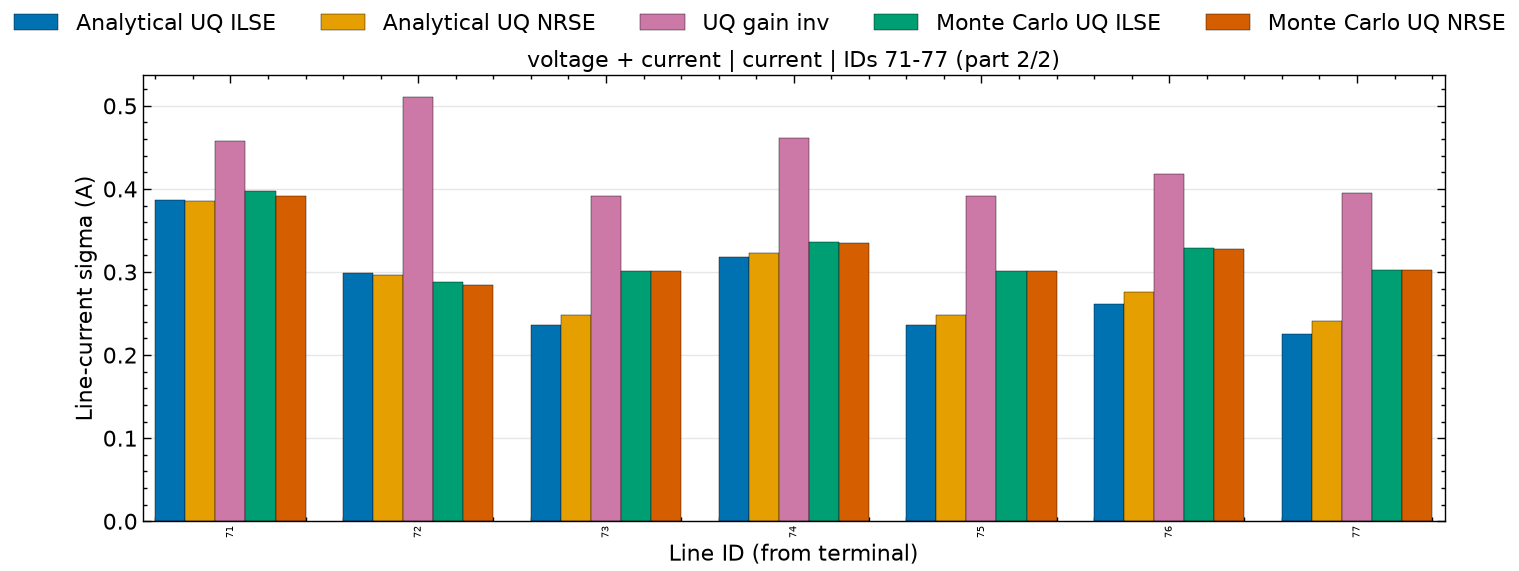

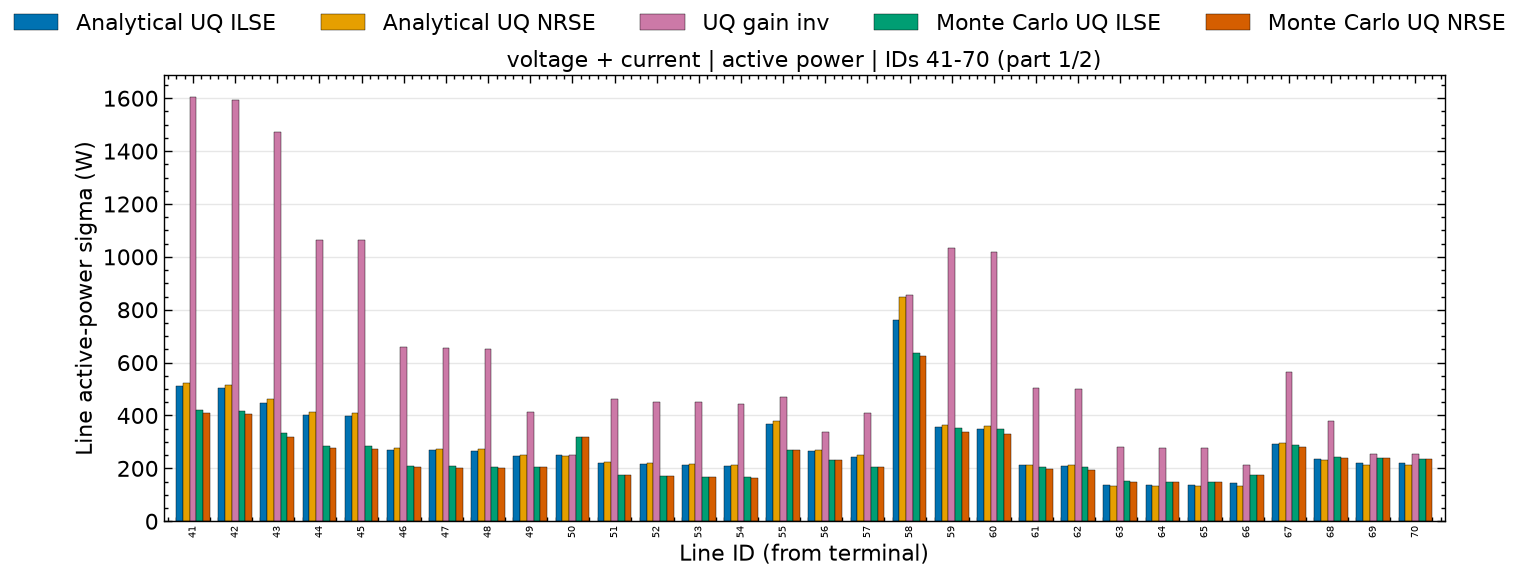

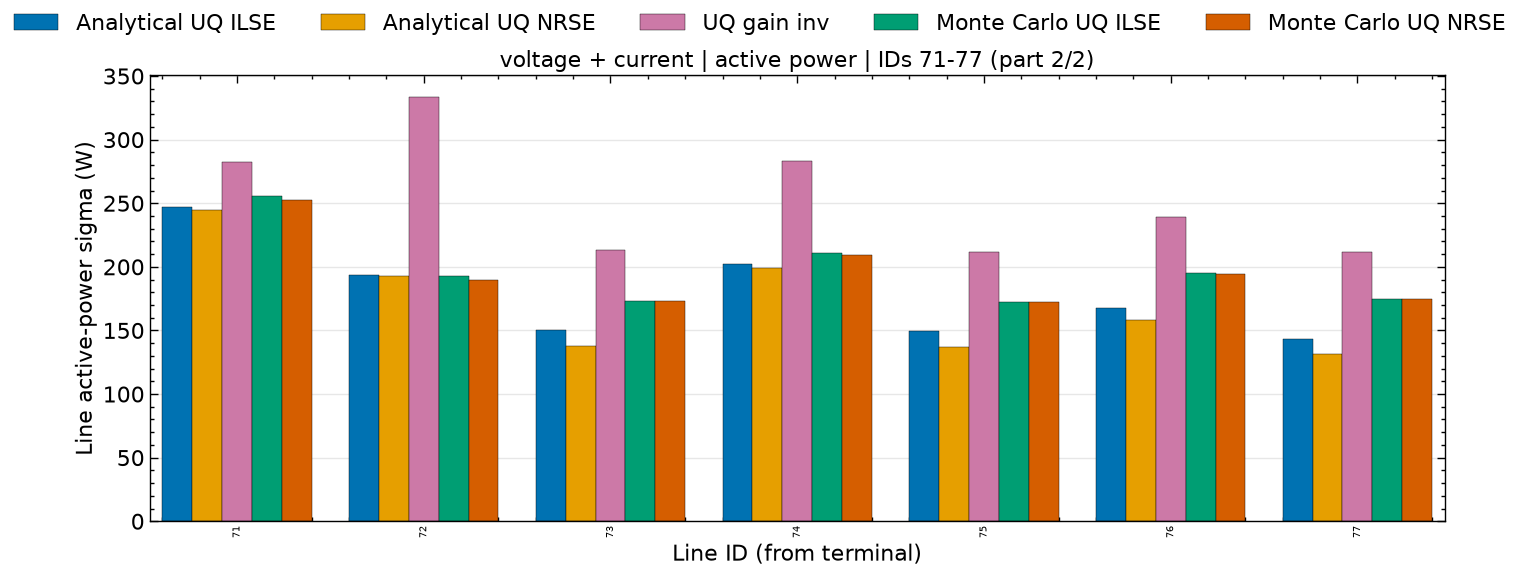

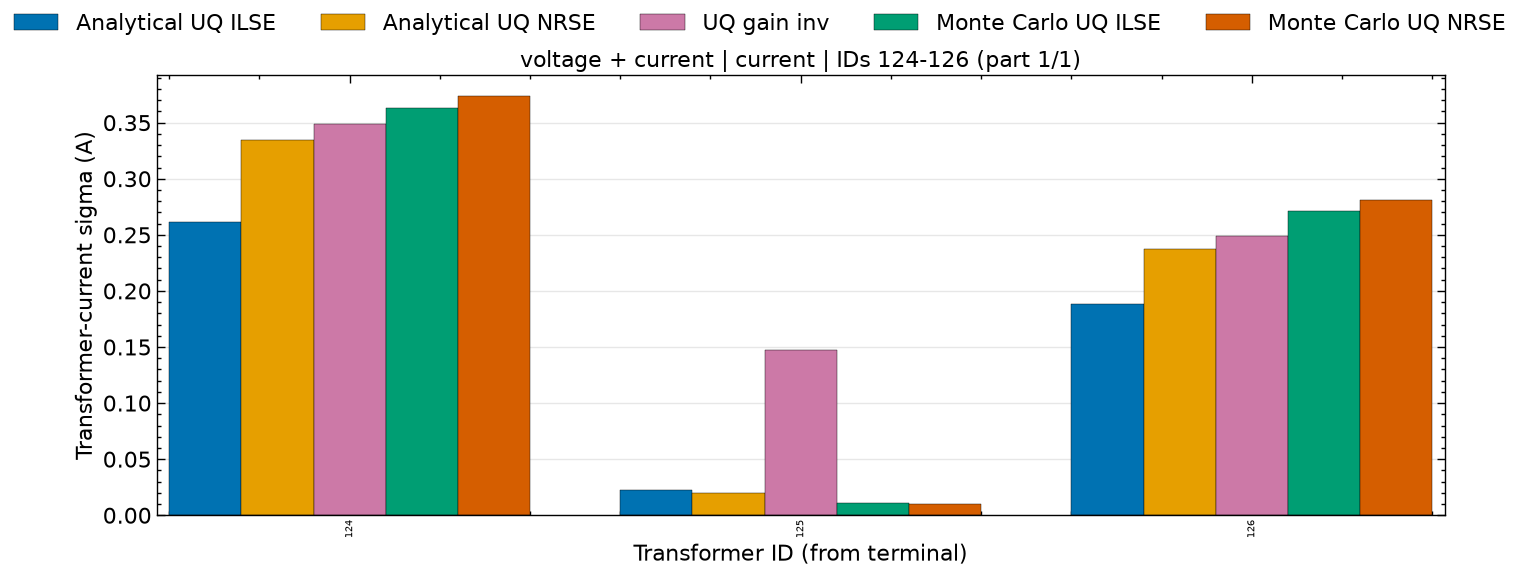

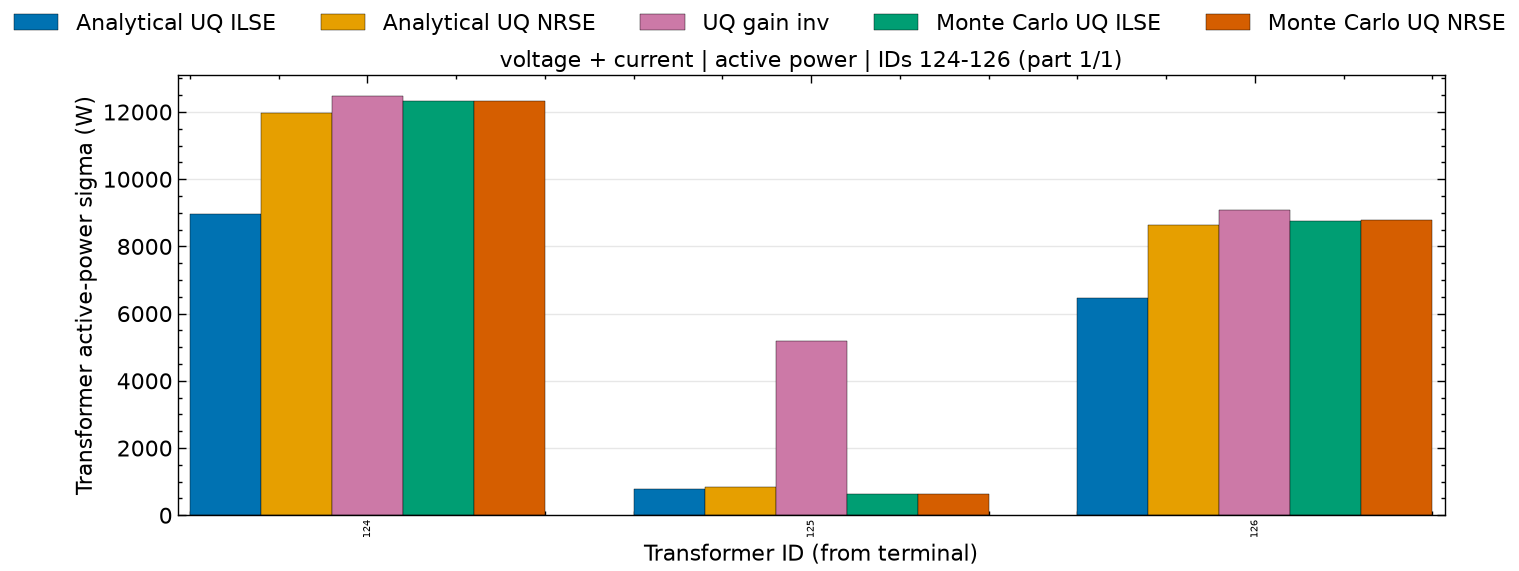

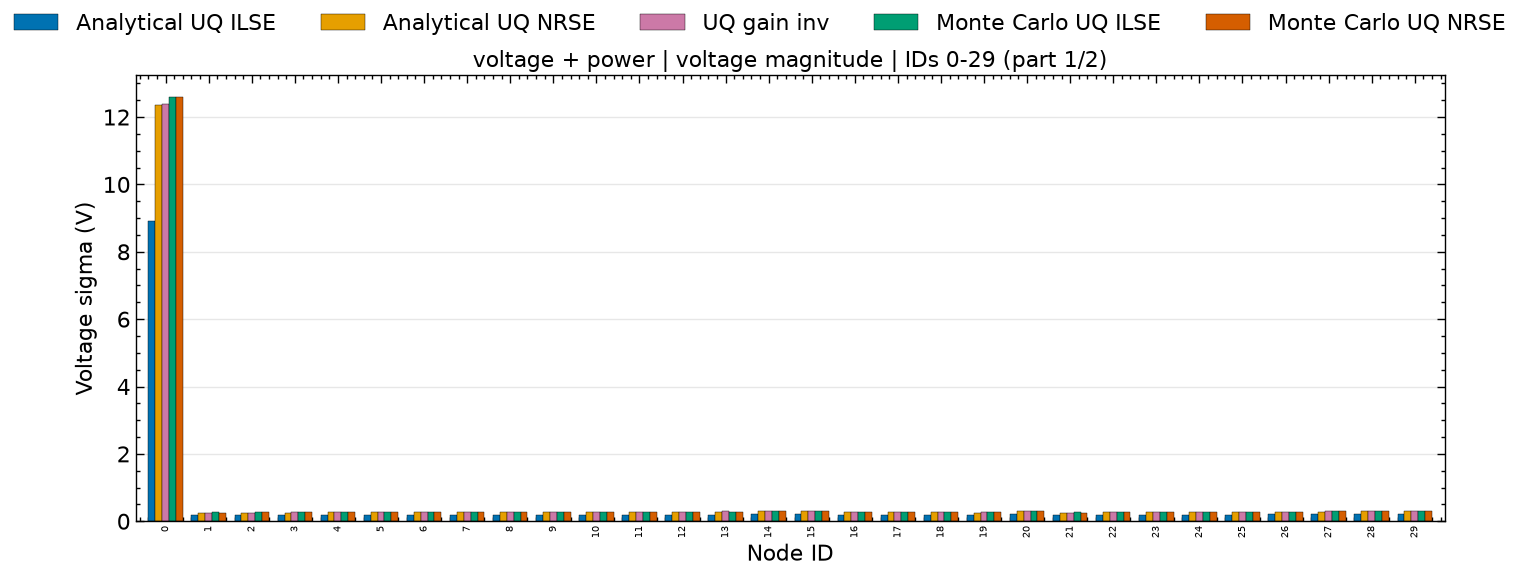

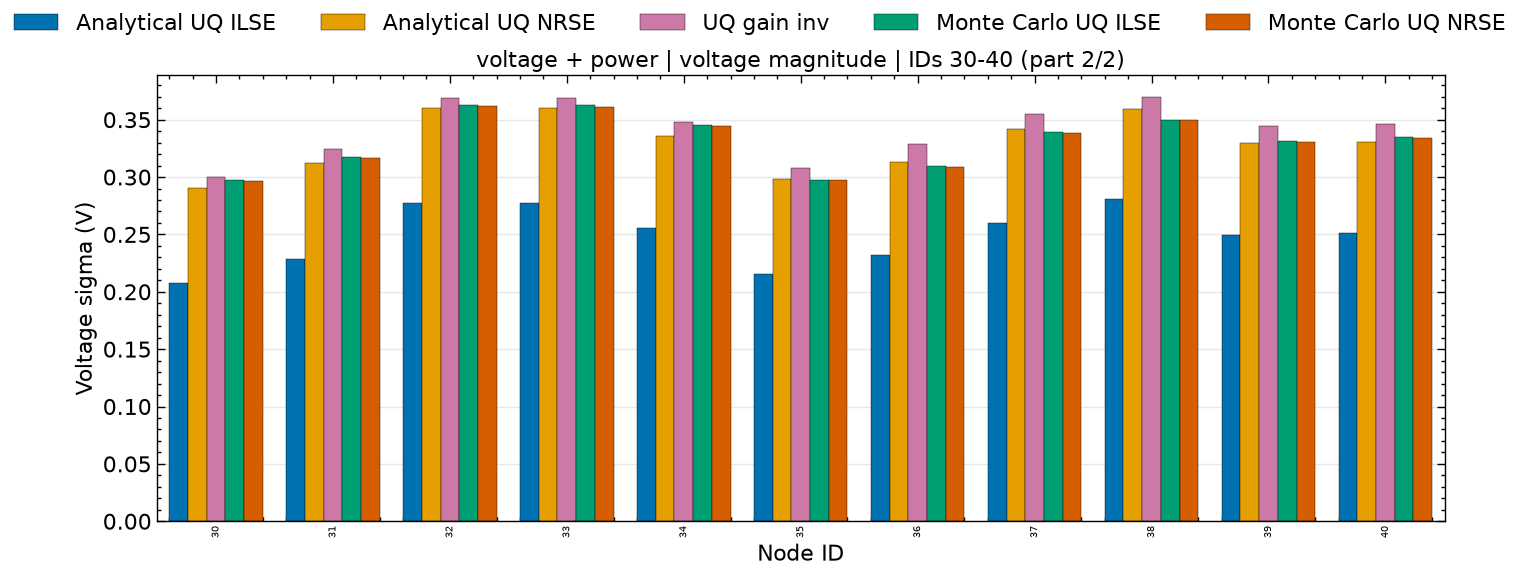

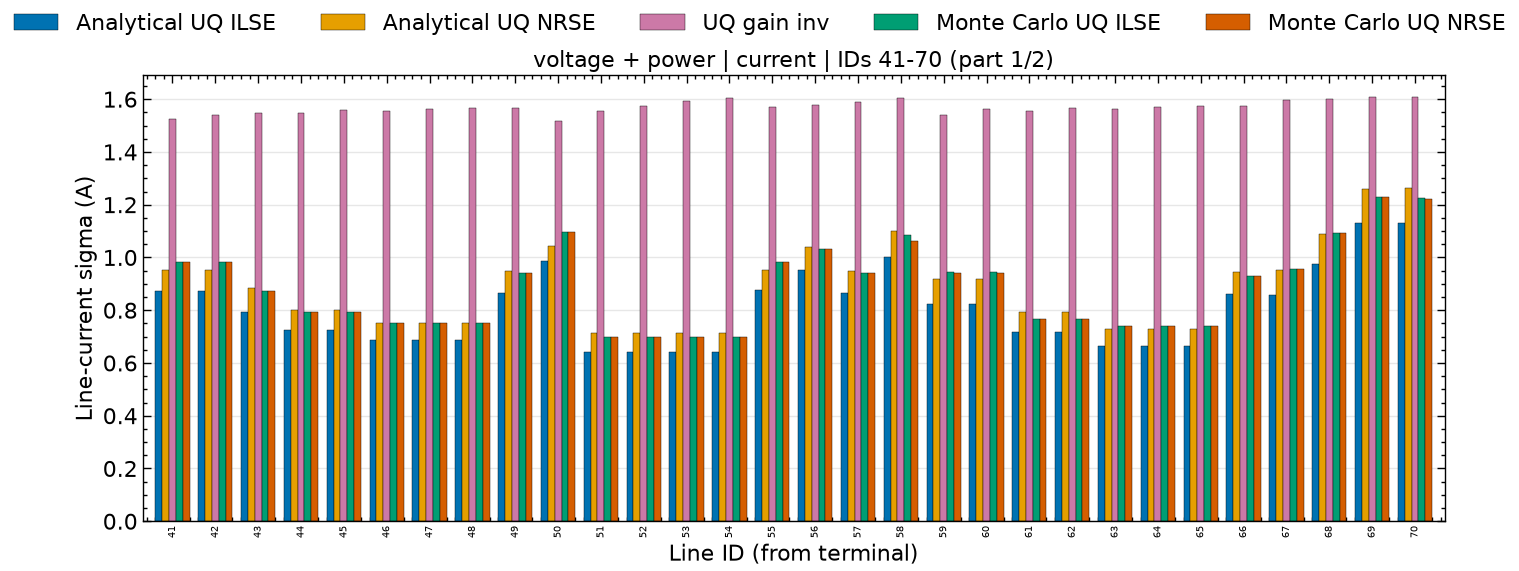

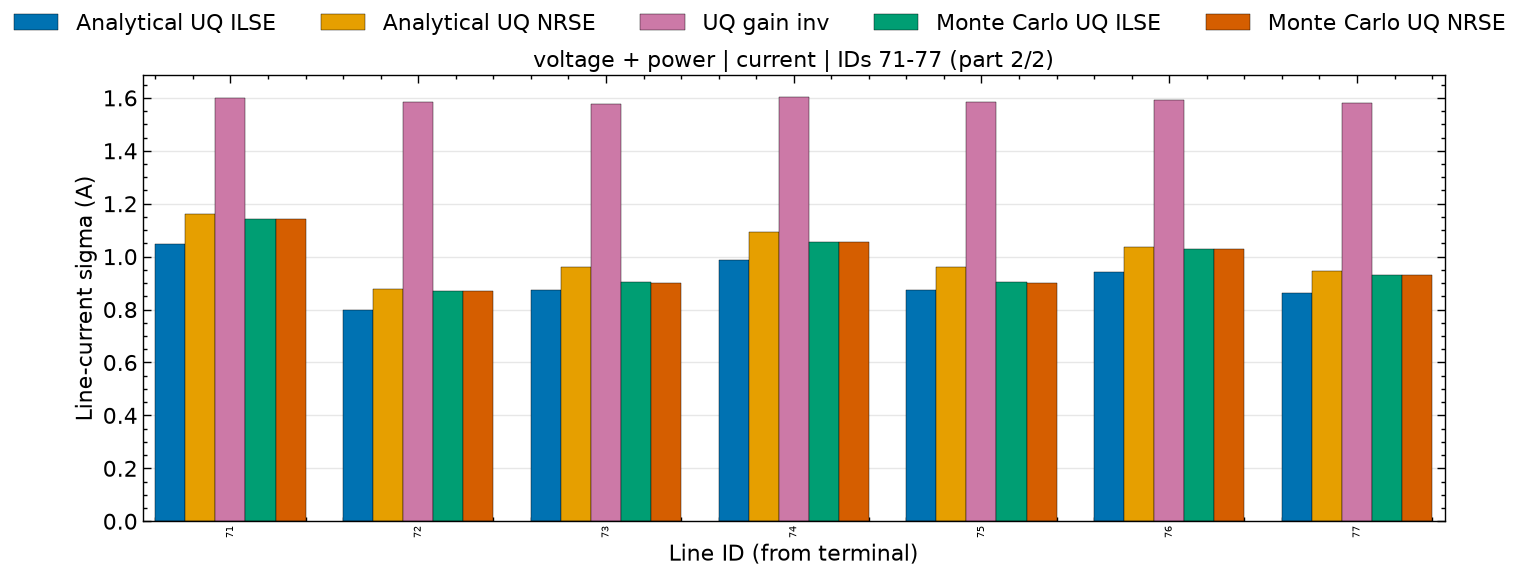

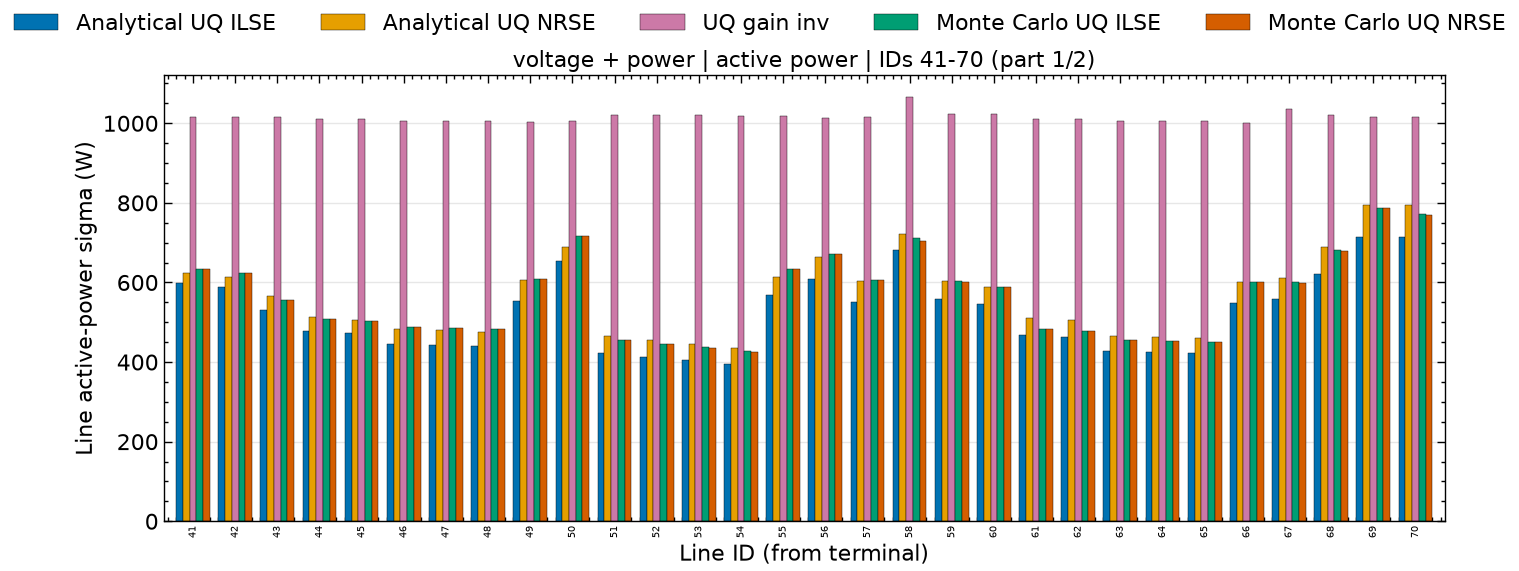

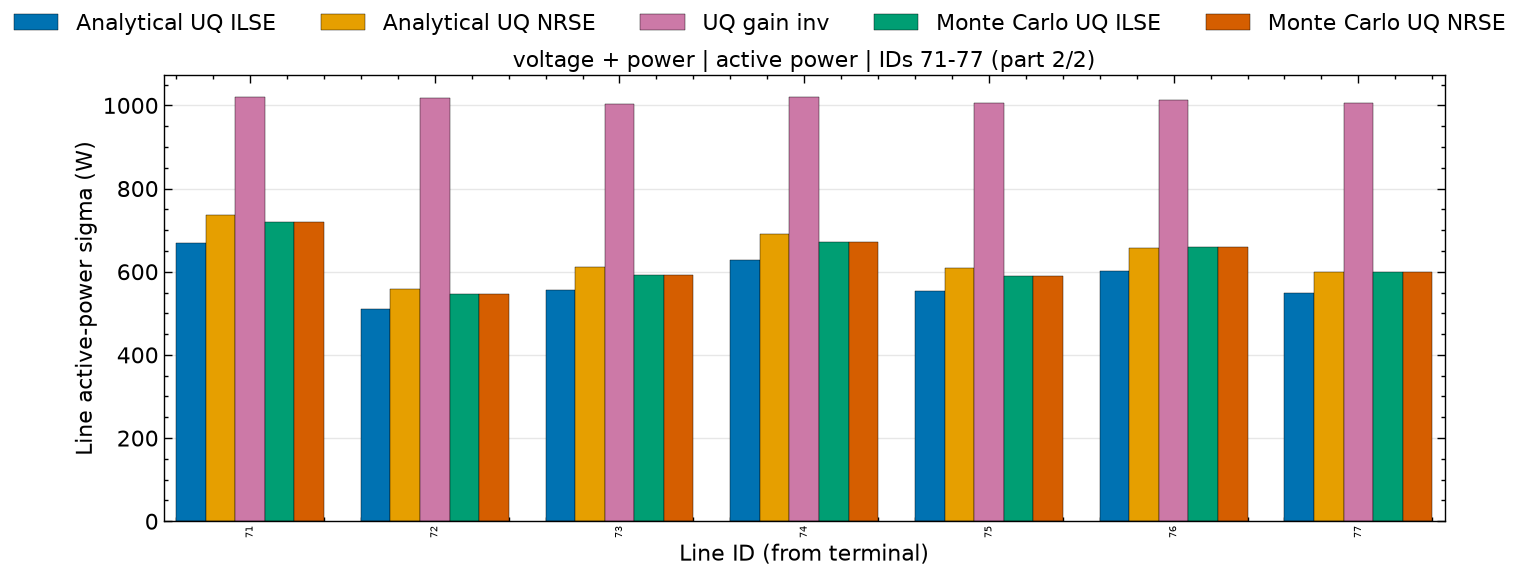

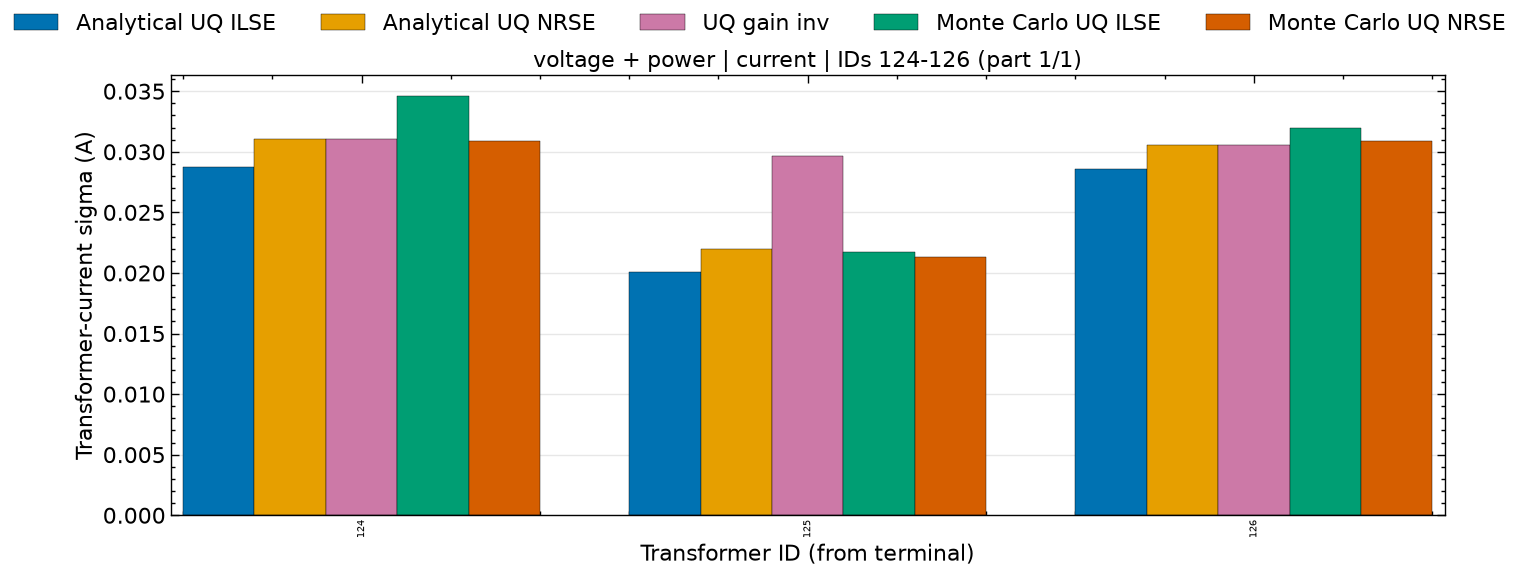

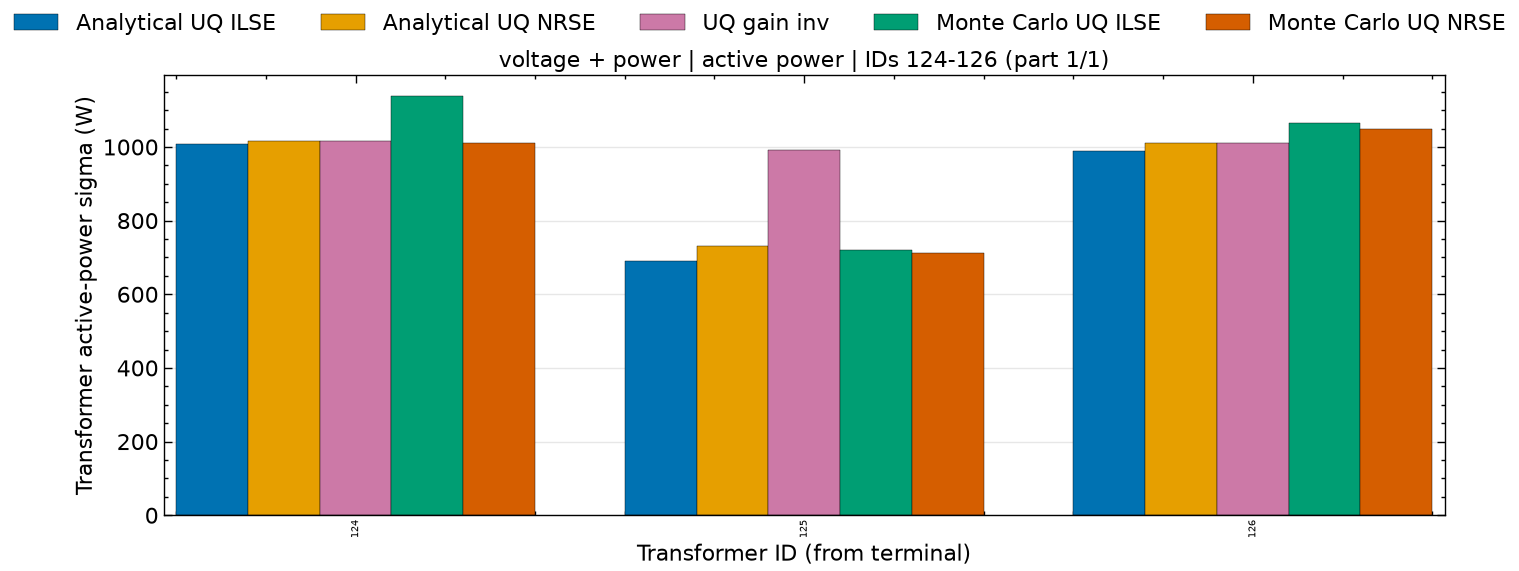

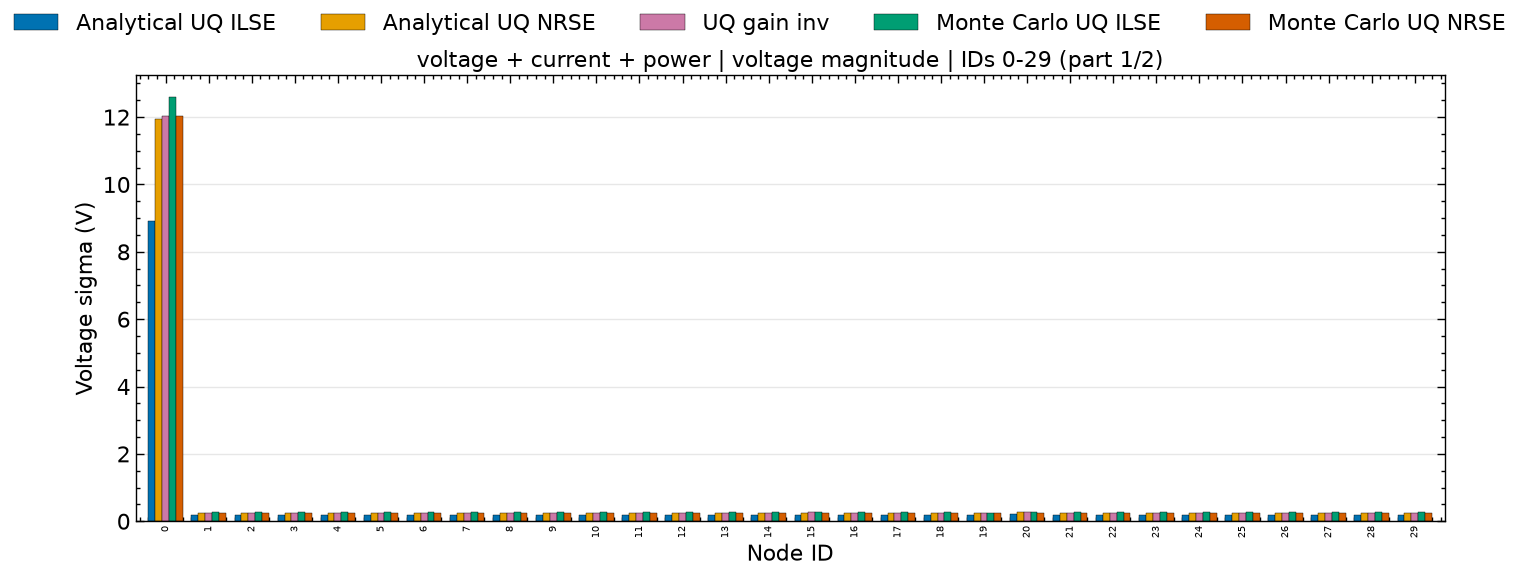

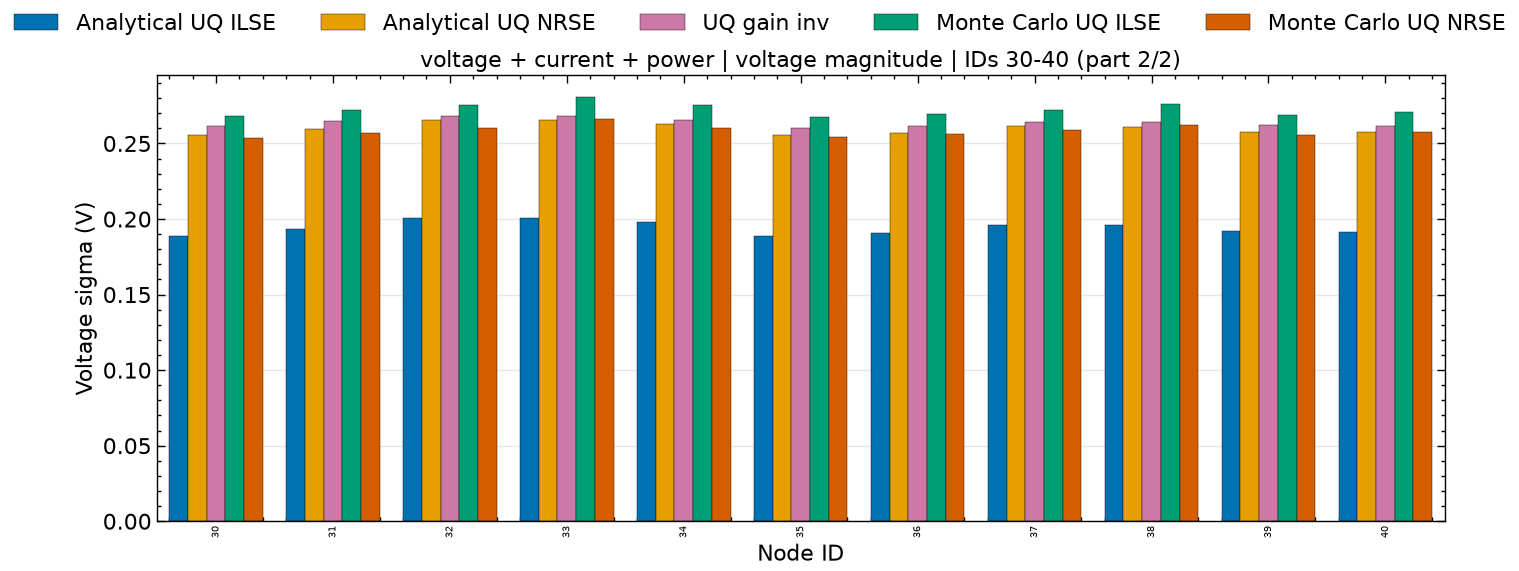

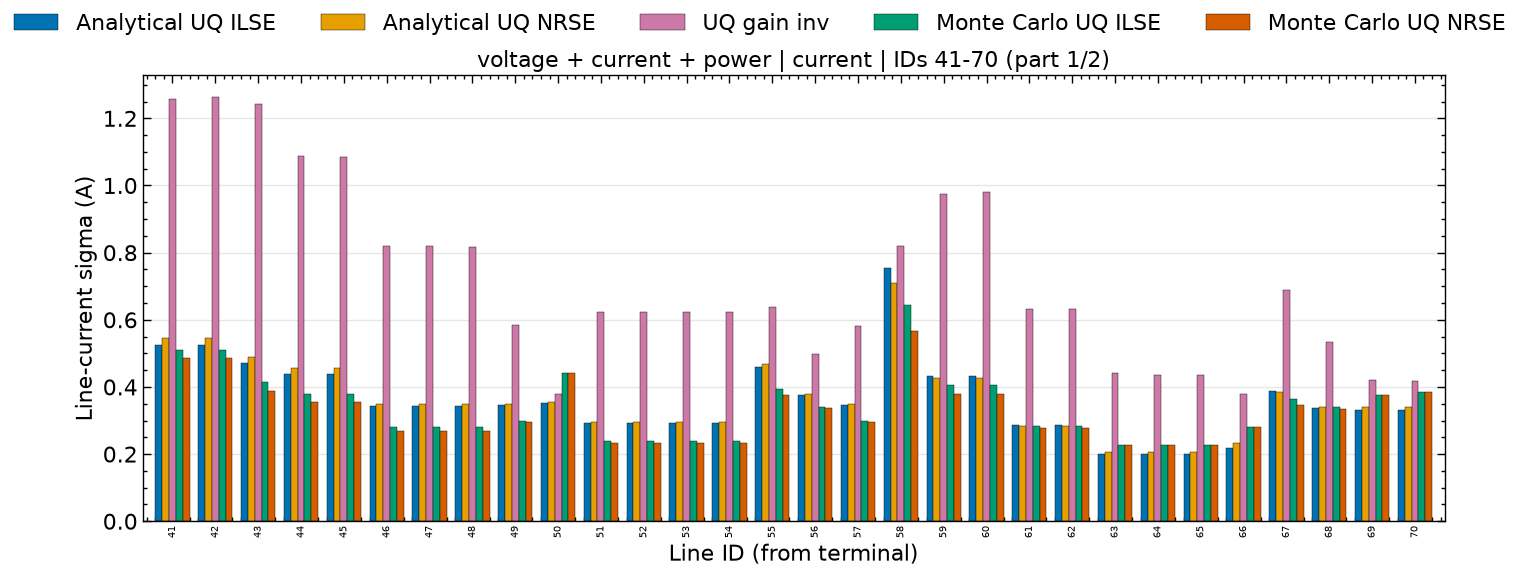

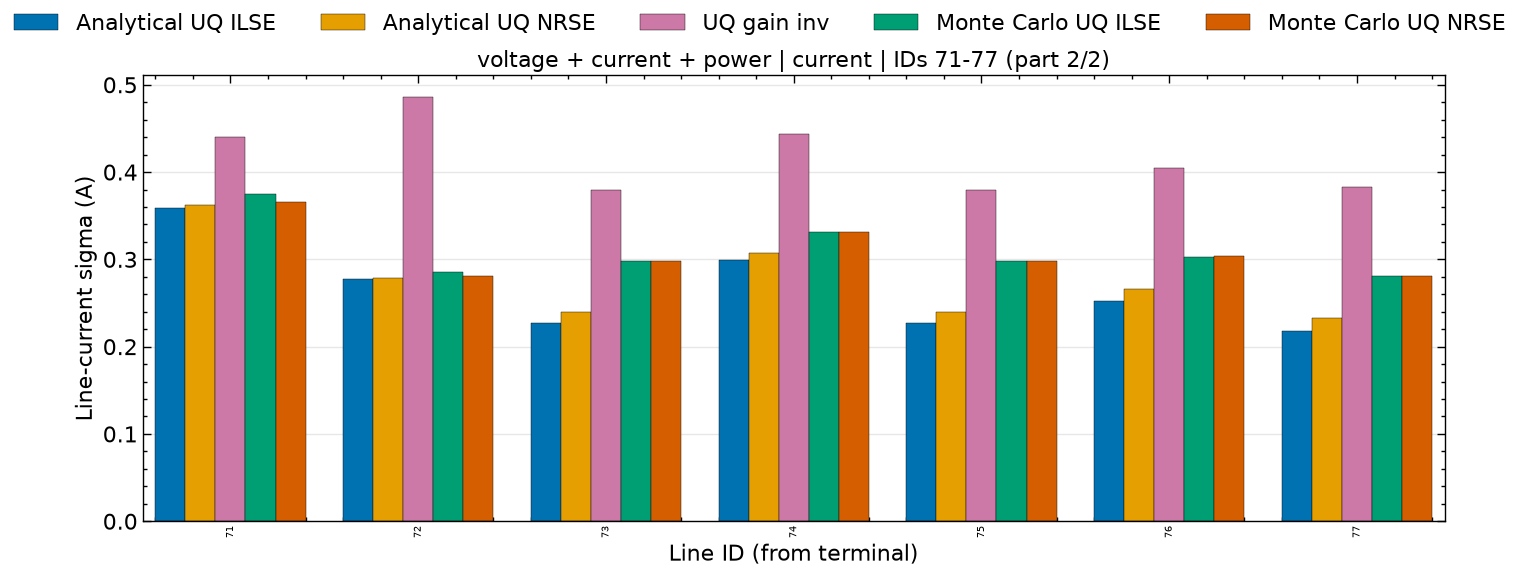

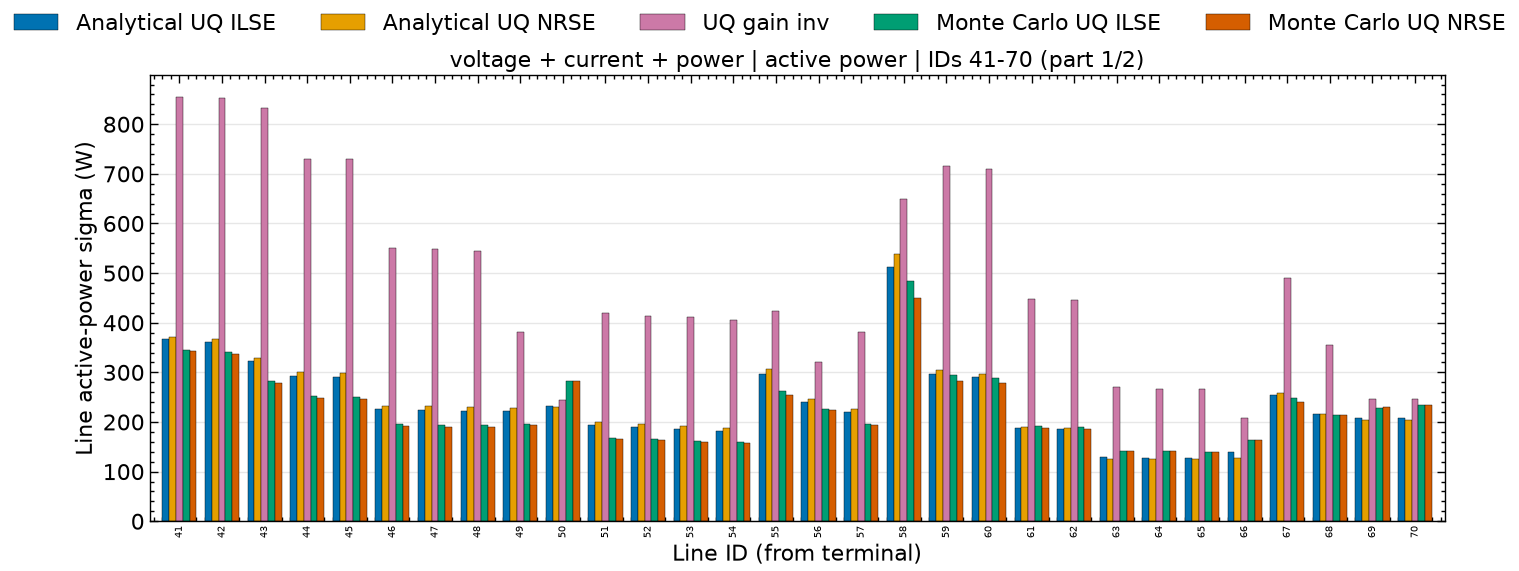

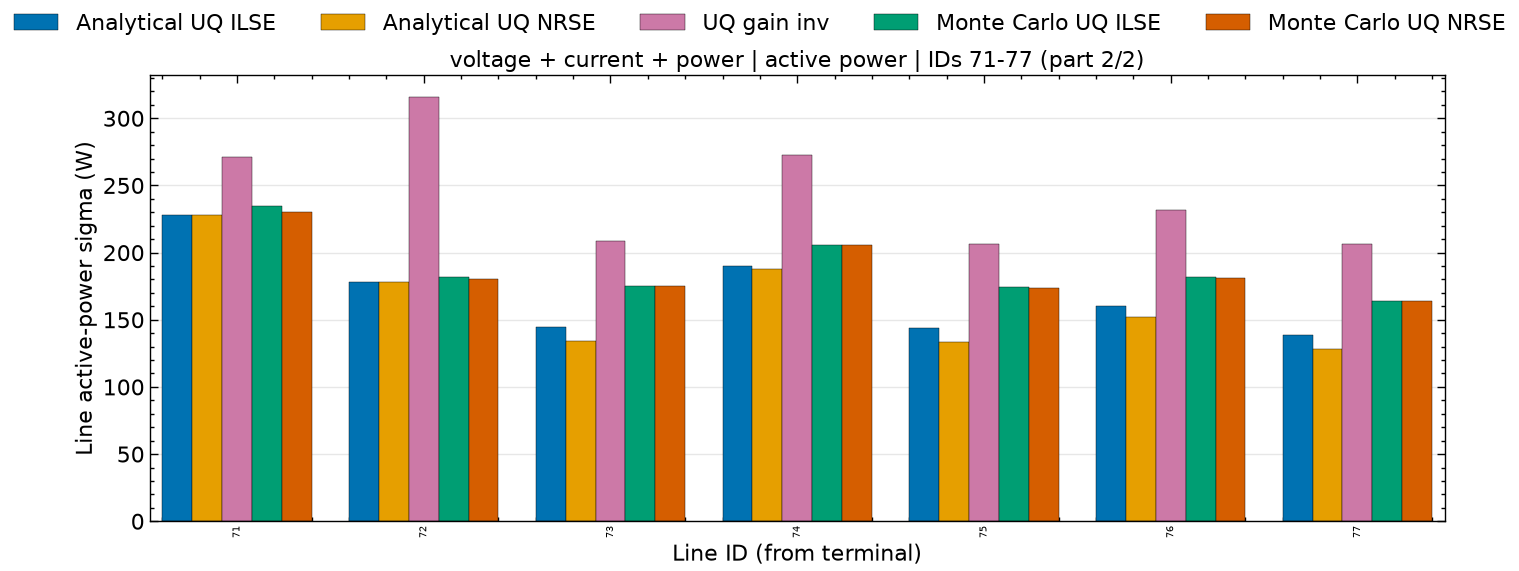

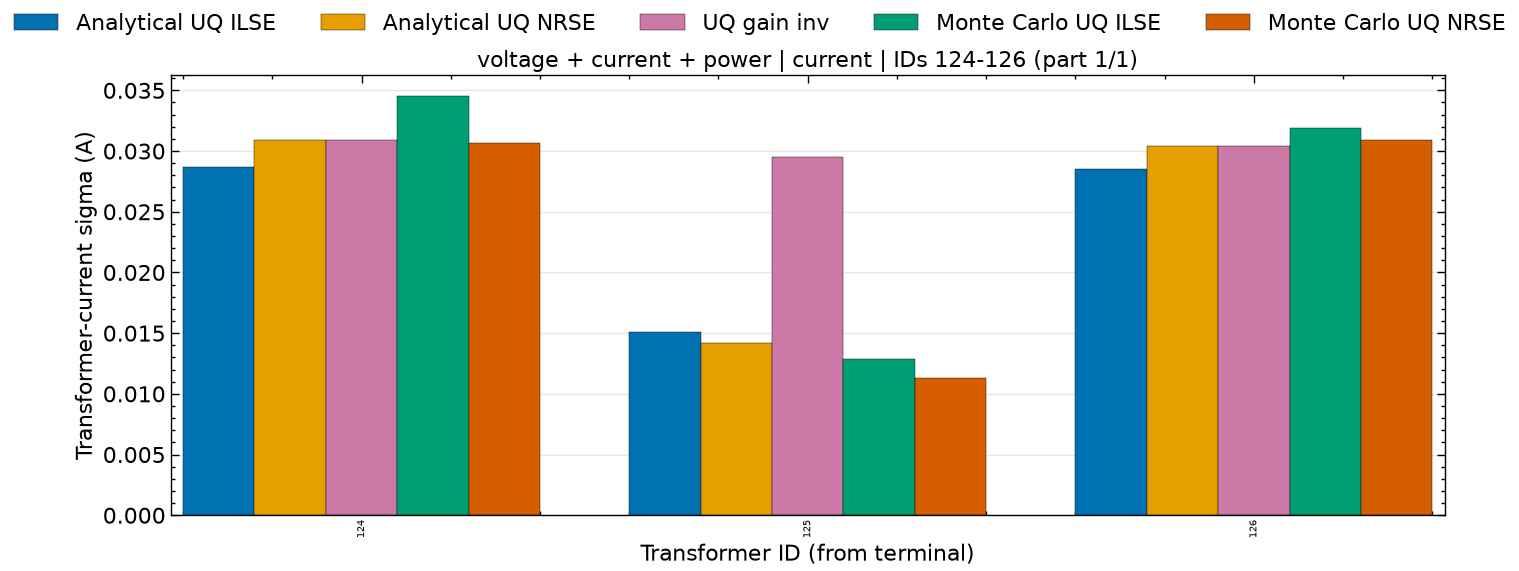

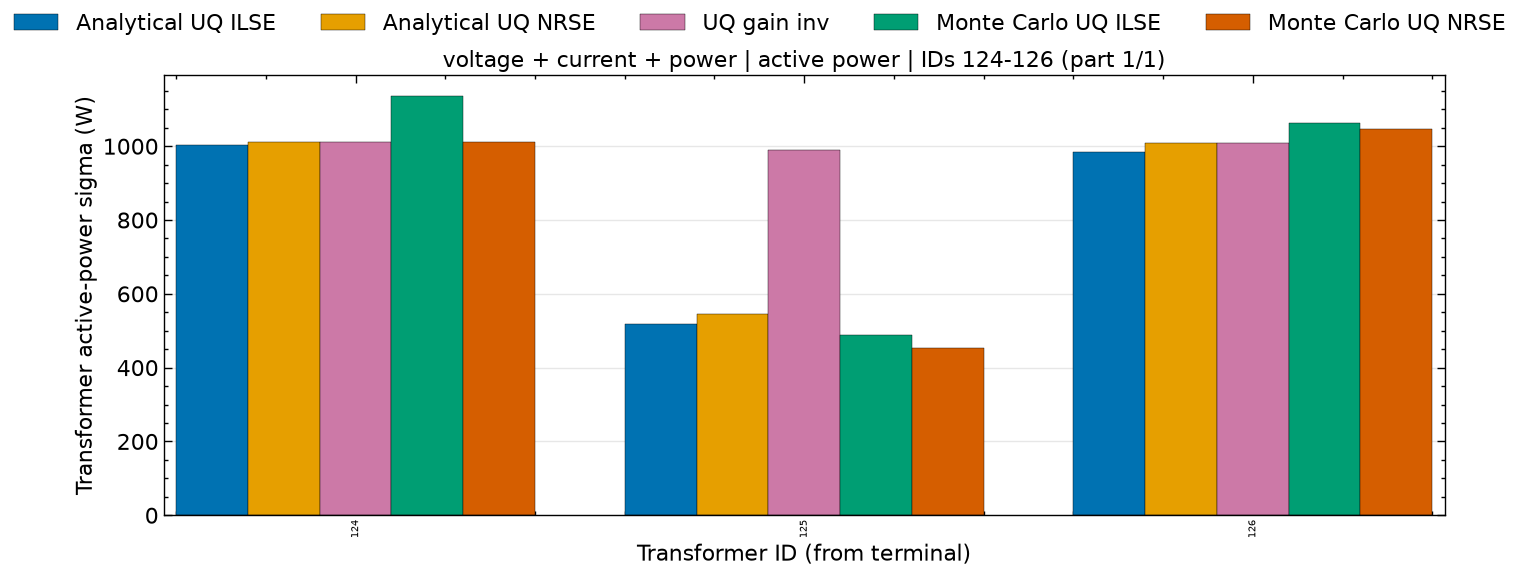

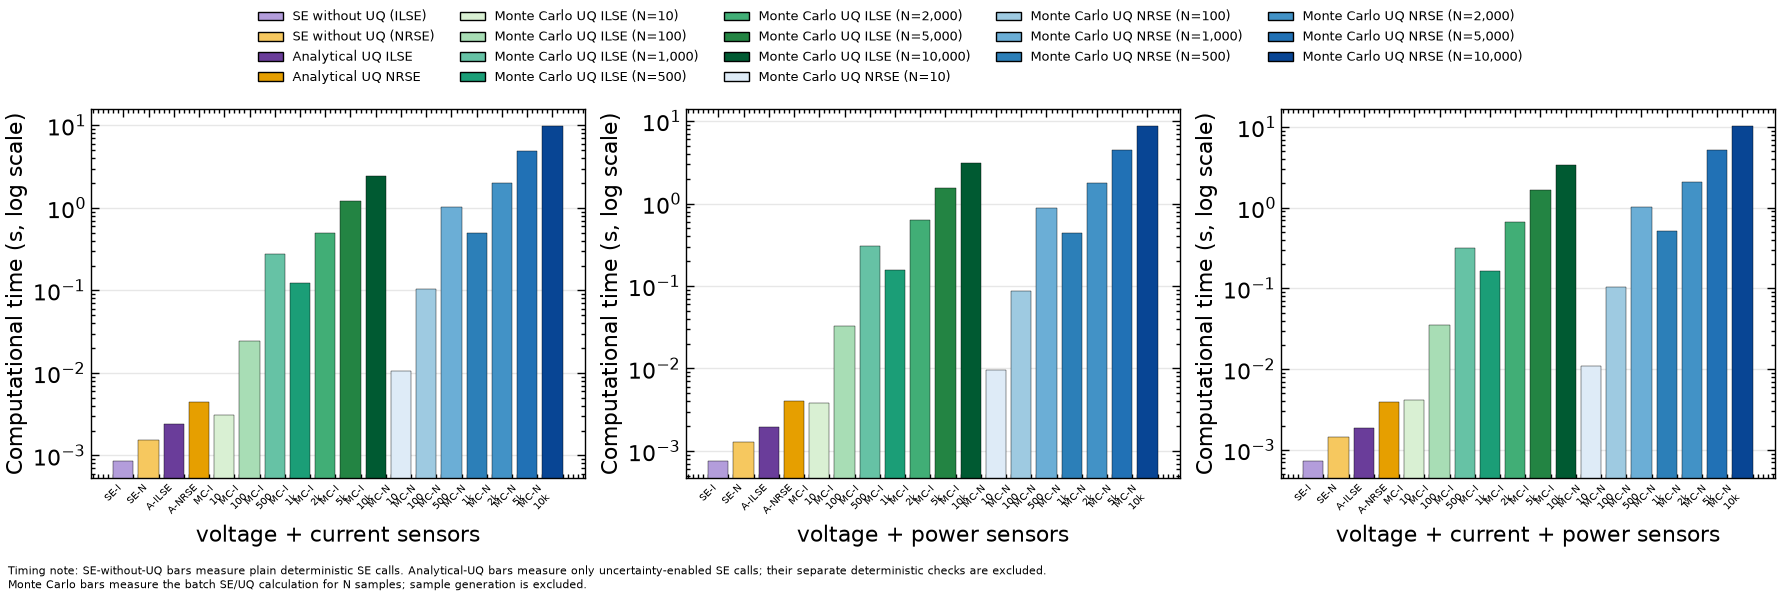

In [13]:
# ruff: noqa: E501
from pathlib import Path

from matplotlib.patches import Patch

try:
    import scienceplots  # noqa: F401
except ImportError:
    plot_style = ["default"]
else:
    plot_style = ["science", "notebook"]

method_columns = [
    ("Analytical UQ ILSE sigma", "Analytical UQ ILSE", "#0072B2"),
    ("Analytical UQ NRSE sigma", "Analytical UQ NRSE", "#E69F00"),
    ("UQ gain inv sigma", "UQ gain inv", "#CC79A7"),
    ("Monte Carlo UQ ILSE sigma", "Monte Carlo UQ ILSE", "#009E73"),
    ("Monte Carlo UQ NRSE sigma", "Monte Carlo UQ NRSE", "#D55E00"),
]
plot_definitions = [
    ("node", "voltage magnitude", "Voltage sigma (V)", "Node ID", None),
    ("line", "current", "Line-current sigma (A)", "Line ID (from terminal)", "from"),
    ("line", "active power", "Line active-power sigma (W)", "Line ID (from terminal)", "from"),
    ("transformer", "current", "Transformer-current sigma (A)", "Transformer ID (from terminal)", "from"),
    ("transformer", "active power", "Transformer active-power sigma (W)", "Transformer ID (from terminal)", "from"),
]


def plot_sigma_bars(ax, filtered, plot_definition):
    _, _, ylabel, xlabel, _ = plot_definition
    positions = np.arange(len(filtered))
    bar_width = 0.16
    offsets = (np.arange(len(method_columns)) - (len(method_columns) - 1) / 2) * bar_width
    for offset, (column, label, color) in zip(offsets, method_columns, strict=True):
        ax.bar(
            positions + offset,
            filtered[column].to_numpy(),
            width=bar_width,
            label=label,
            color=color,
            edgecolor="black",
            linewidth=0.3,
        )
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_xticks(positions)
    ax.set_xticklabels(filtered["id"].astype(str).tolist(), rotation=90, fontsize=7)
    ax.grid(axis="y", visible=True, alpha=0.3)
    ax.set_axisbelow(True)
    ax.margins(x=0.01)


figure_directory = output_directory / "figures"
figure_directory.mkdir(parents=True, exist_ok=True)

node_ids_for_plot = sorted(int(node_id) for node_id in base_input_data[ComponentType.node][AttributeType.id])
node_index = {node_id: index for index, node_id in enumerate(node_ids_for_plot)}
topology_edges = [
    (int(row[AttributeType.from_node]), int(row[AttributeType.to_node])) for row in base_input_data[ComponentType.line]
]
topology_edges.extend(
    (int(row[AttributeType.from_node]), int(row[AttributeType.to_node]))
    for row in base_input_data[ComponentType.transformer]
)
topology_adjacency = {node_id: [] for node_id in node_ids_for_plot}
for from_node, to_node in topology_edges:
    topology_adjacency[from_node].append(to_node)
    topology_adjacency[to_node].append(from_node)
root_node = int(base_input_data[ComponentType.source][AttributeType.node][0])
parent = {root_node: None}
depth = {root_node: 0}
children = {node_id: [] for node_id in node_ids_for_plot}
queue = [root_node]
for current_node in queue:
    for adjacent_node in sorted(topology_adjacency[current_node]):
        if adjacent_node in parent:
            continue
        parent[adjacent_node] = current_node
        depth[adjacent_node] = depth[current_node] + 1
        children[current_node].append(adjacent_node)
        queue.append(adjacent_node)
if len(parent) != len(node_ids_for_plot):
    raise ValueError("CIGRE LV topology must be connected")

leaf_x = {}
for leaf_number, leaf_node in enumerate(node_id for node_id in node_ids_for_plot if not children[node_id]):
    leaf_x[leaf_node] = float(leaf_number)
node_x = {}
for node_id in reversed(queue):
    node_x[node_id] = (
        leaf_x[node_id] if not children[node_id] else np.mean([node_x[child] for child in children[node_id]])
    )
topology_positions = {node_id: np.array([node_x[node_id], -float(depth[node_id])]) for node_id in node_ids_for_plot}
topology_line_rows = {int(row[AttributeType.id]): row for row in base_input_data[ComponentType.line]}
topology_transformer_rows = {int(row[AttributeType.id]): row for row in base_input_data[ComponentType.transformer]}
network_size_label = (
    f"{len(node_ids_for_plot)} buses, {len(topology_line_rows)} lines, {len(topology_transformer_rows)} transformers"
)
with plt.style.context(plot_style), plt.rc_context({"text.usetex": False}):
    topology_figure, topology_axis = plt.subplots(figsize=(14, 9))
    for line_id, row in topology_line_rows.items():
        from_node = int(row[AttributeType.from_node])
        to_node = int(row[AttributeType.to_node])
        x_values = [topology_positions[from_node][0], topology_positions[to_node][0]]
        y_values = [topology_positions[from_node][1], topology_positions[to_node][1]]
        is_closed = bool(row[AttributeType.from_status]) and bool(row[AttributeType.to_status])
        topology_axis.plot(
            x_values,
            y_values,
            color="#0072B2" if is_closed else "#D55E00",
            linestyle="-" if is_closed else "--",
            linewidth=0.8 if is_closed else 2.0,
            alpha=0.65,
        )
        if not is_closed:
            topology_axis.text(
                sum(x_values) / 2,
                sum(y_values) / 2,
                str(line_id),
                color="#991b1b",
                fontsize=7,
                ha="center",
                va="center",
                bbox={"facecolor": "#fde2e1", "edgecolor": "none", "pad": 1.2},
            )
    for row in topology_transformer_rows.values():
        from_node = int(row[AttributeType.from_node])
        to_node = int(row[AttributeType.to_node])
        topology_axis.plot(
            [topology_positions[from_node][0], topology_positions[to_node][0]],
            [topology_positions[from_node][1], topology_positions[to_node][1]],
            color="#7B2CBF",
            linewidth=2.6,
            alpha=0.9,
        )
    topology_axis.scatter(
        [topology_positions[node_id][0] for node_id in node_ids_for_plot],
        [topology_positions[node_id][1] for node_id in node_ids_for_plot],
        s=20,
        color="#E69F00",
        edgecolor="black",
        linewidth=0.25,
        zorder=3,
    )
    for node_id in node_ids_for_plot:
        topology_axis.annotate(
            str(node_id),
            topology_positions[node_id],
            xytext=(4, 0),
            textcoords="offset points",
            fontsize=6,
            va="center",
        )
    topology_axis.set_title(f"CIGRE LV topology ({network_size_label})", pad=12)
    topology_axis.axis("off")
    topology_axis.legend(
        handles=[
            plt.Line2D([0], [0], color="#0072B2", linewidth=1.4, label="Line"),
            plt.Line2D([0], [0], color="#7B2CBF", linewidth=2.6, label="Transformer"),
        ],
        loc="upper right",
    )
    topology_figure.tight_layout()
    topology_figure.savefig(figure_directory / "cigre_lv_topology.pdf")
    topology_figure.savefig(figure_directory / "cigre_lv_topology.png", dpi=300)
    plt.show()
setting_slugs = {
    "voltage + current": "voltage_current",
    "voltage + power": "voltage_power",
    "voltage + current + power": "voltage_current_power",
}
plot_chunk_size = 30

with plt.style.context(plot_style), plt.rc_context({"text.usetex": False}):
    for setting in sensor_settings:
        for plot_definition in plot_definitions:
            component, quantity, _, _, terminal = plot_definition
            filtered = comparison[
                (comparison["sensor setting"] == setting)
                & (comparison["component"] == component)
                & (comparison["quantity"] == quantity)
            ].copy()
            if terminal is not None:
                filtered = filtered[filtered["terminal"] == terminal]
            filtered = filtered.sort_values("id").reset_index(drop=True)
            chunk_count = (len(filtered) + plot_chunk_size - 1) // plot_chunk_size
            quantity_slug = quantity.replace(" ", "_")
            for chunk_number, chunk_start in enumerate(
                range(0, len(filtered), plot_chunk_size),
                start=1,
            ):
                chunk = filtered.iloc[chunk_start : chunk_start + plot_chunk_size]
                chunk_end = chunk_start + len(chunk)
                figure, axis = plt.subplots(figsize=(14, 6))
                plot_sigma_bars(axis, chunk, plot_definition)
                axis.set_title(
                    f"{setting} | {quantity} | IDs {int(chunk['id'].iloc[0])}-{int(chunk['id'].iloc[-1])} "
                    f"(part {chunk_number}/{chunk_count})"
                )
                handles, labels = axis.get_legend_handles_labels()
                figure.legend(handles, labels, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 0.98))
                figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.91))
                figure_path = figure_directory / (
                    f"cigre_lv_{setting_slugs[setting]}_{component}_{quantity_slug}_part_{chunk_number:02d}"
                )
                figure.savefig(figure_path.with_suffix(".pdf"))
                figure.savefig(figure_path.with_suffix(".png"), dpi=300)
                plt.show()
                plt.close(figure)

monte_carlo_baseline_sample_count = 1_000
timing_sample_counts = [
    *monte_carlo_timing_sample_counts[:2],
    monte_carlo_baseline_sample_count,
    *monte_carlo_timing_sample_counts[2:],
]
timing_sample_labels = dict(zip(timing_sample_counts, ["10", "100", "500", "1k", "2k", "5k", "10k"], strict=True))
timing_ilse_colors = ["#D9F0D3", "#A8DDB5", "#66C2A5", "#1B9E77", "#41AE76", "#238443", "#005A32"]
timing_nrse_colors = ["#DEEBF7", "#9ECAE1", "#6BAED6", "#2C7FB8", "#4292C6", "#2171B5", "#084594"]
timing_method_columns = (
    [
        ("SE without UQ (ILSE)", "SE-I", "#B39DDB"),
        ("SE without UQ (NRSE)", "SE-N", "#F6C85F"),
        ("Analytical UQ ILSE", "A-ILSE", "#6A3D9A"),
        ("Analytical UQ NRSE", "A-NRSE", "#E69F00"),
    ]
    + [
        (f"Monte Carlo UQ ILSE (N={sample_count:,})", f"MC-I\n{timing_sample_labels[sample_count]}", color)
        for sample_count, color in zip(timing_sample_counts, timing_ilse_colors, strict=True)
    ]
    + [
        (f"Monte Carlo UQ NRSE (N={sample_count:,})", f"MC-N\n{timing_sample_labels[sample_count]}", color)
        for sample_count, color in zip(timing_sample_counts, timing_nrse_colors, strict=True)
    ]
)

with plt.style.context(plot_style), plt.rc_context({"text.usetex": False}):
    timing_figure, timing_axes = plt.subplots(1, 3, figsize=(18, 6))
    for axis, setting in zip(timing_axes, sensor_settings, strict=True):
        values = [
            deterministic_seconds[setting, "Analytical UQ ILSE"],
            deterministic_seconds[setting, "Analytical UQ NRSE"],
            analytical_seconds[setting, "Analytical UQ ILSE"],
            analytical_seconds[setting, "Analytical UQ NRSE"],
            *[
                monte_carlo_seconds[setting, "Analytical UQ ILSE"]
                if sample_count == monte_carlo_baseline_sample_count
                else monte_carlo_scaling_seconds[setting, "Analytical UQ ILSE", sample_count]
                for sample_count in timing_sample_counts
            ],
            *[
                monte_carlo_seconds[setting, "Analytical UQ NRSE"]
                if sample_count == monte_carlo_baseline_sample_count
                else monte_carlo_scaling_seconds[setting, "Analytical UQ NRSE", sample_count]
                for sample_count in timing_sample_counts
            ],
        ]
        labels = [label for _, label, _ in timing_method_columns]
        colors = [color for _, _, color in timing_method_columns]
        axis.bar(np.arange(len(values)), values, color=colors, edgecolor="black", linewidth=0.3)
        axis.set_xlabel(f"{setting} sensors")
        axis.set_ylabel("Computational time (s, log scale)")
        axis.set_yscale("log")
        axis.set_xticks(np.arange(len(values)))
        axis.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
        axis.grid(axis="y", visible=True, alpha=0.3)
        axis.set_axisbelow(True)
    timing_legend_handles = [
        Patch(facecolor=color, edgecolor="black", label=method_name) for method_name, _, color in timing_method_columns
    ]
    timing_figure.legend(
        handles=timing_legend_handles,
        loc="upper center",
        ncol=5,
        fontsize=9,
        bbox_to_anchor=(0.5, 1.0),
    )
    timing_figure.text(
        0.01,
        0.01,
        "Timing note: SE-without-UQ bars measure plain deterministic SE calls. Analytical-UQ bars measure only uncertainty-enabled SE calls; their separate deterministic checks are excluded.\nMonte Carlo bars measure the batch SE/UQ calculation for N samples; sample generation is excluded.",
        ha="left",
        va="bottom",
        fontsize=8,
    )
    timing_figure.tight_layout(rect=(0.0, 0.06, 1.0, 0.84))
    timing_figure.savefig(figure_directory / "cigre_lv_uq_computational_time.pdf")
    timing_figure.savefig(figure_directory / "cigre_lv_uq_computational_time.png", dpi=300)
    plt.show()

## Interpretation

The sensor layout changes both observability and the covariance model. Analytical UQ ILSE and NRSE are method-specific first-order approximations, while Monte Carlo includes the nonlinear estimator response and the public sensor-coordinate sampling. All 1,000 Monte Carlo scenarios converged for both ILSE and NRSE in every layout.

`UQ gain inv` is a conventional first-order NRSE covariance baseline evaluated at the converged PGM state. Because its gain matrix excludes the network's 25 exact zero-injection buses, its larger differences from Analytical UQ NRSE and Monte Carlo UQ NRSE are expected.

**Accuracy ranking.** Monte Carlo UQ NRSE is the reference and is therefore not ranked. Rankings run from most accurate to least accurate using median APE as the primary metric and mean APE to break ties. Across the nine voltage/current/power and sensor-layout combinations, the overall ranking is:

1. **Monte Carlo UQ ILSE** — first in 8 of 9 combinations; mean ordinal rank 1.22.
2. **Analytical UQ NRSE** — first for voltage sigmas in the combined layout; mean ordinal rank 2.11.
3. **Analytical UQ ILSE** — mean ordinal rank 3.11.
4. **UQ gain inv** — mean ordinal rank 3.56 and last in every current- and power-sigma comparison.

The category-specific rankings are:

- **Voltage sigmas**
  - voltage + current: Monte Carlo UQ ILSE, Analytical UQ NRSE, UQ gain inv, Analytical UQ ILSE;
  - voltage + power: Monte Carlo UQ ILSE, Analytical UQ NRSE, UQ gain inv, Analytical UQ ILSE;
  - voltage + current + power: Analytical UQ NRSE, UQ gain inv, Monte Carlo UQ ILSE, Analytical UQ ILSE.
- **Current sigmas** — for all three layouts: Monte Carlo UQ ILSE, Analytical UQ NRSE, Analytical UQ ILSE, UQ gain inv.
- **Power sigmas**
  - voltage + current: Monte Carlo UQ ILSE, Analytical UQ ILSE, Analytical UQ NRSE, UQ gain inv;
  - voltage + power: Monte Carlo UQ ILSE, Analytical UQ NRSE, Analytical UQ ILSE, UQ gain inv;
  - voltage + current + power: Monte Carlo UQ ILSE, Analytical UQ ILSE, Analytical UQ NRSE, UQ gain inv.

Median APE provides the robust central ranking. Mean and P90 APE expose large misses: for example, the gain-inverse current-sigma mean APE ranges from 74% to 170%, substantially above its already large median. The power category contains 50 zero-reference outputs per method/layout; APE omits them, while mean sAPE includes them and reveals disagreement at those zero-sigma outputs. Spearman rho measures similarity of ranking across outputs, not closeness of the sigma values.